In [1]:
import dolfin
print("dolfin version:", dolfin.__version__)

dolfin version: 2019.1.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from time import time
from itertools import product

from scipy.sparse import csr_matrix
from scipy.sparse import save_npz, load_npz

import os

from dolfin import *

In [3]:
from tqdm import tqdm  # pour les barres de progression dans les boucles

In [4]:
mesh_size = 200 
FE_type = "Lagrange"
degree = 2

mesh = UnitSquareMesh(mesh_size, mesh_size)
V = FunctionSpace(mesh, FE_type, degree)
print("Number of vertices:", mesh.num_vertices())

lines = {"mesh_size": mesh_size, "FE_type": FE_type, "degree": degree}
df_mesh_info = pd.DataFrame(lines, index=[0])

Number of vertices: 40401


In [5]:
# Boundary condition
class ConditionalBC(UserExpression):
    def eval(self, values, x):
        if x[0] < 0.1 and x[1] > 0.9:
            values[0] = 4.0
        elif x[1] < 0.1:
            values[0] = 1.0
        else:
            values[0] = 0.0
    def value_shape(self):
        return ()

u_D = ConditionalBC(degree=0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

zero = Constant(0.0)
bc_zero = DirichletBC(V, zero, boundary)

# Define lifting
u_L = Function(V)
bc.apply(u_L.vector())  # fills u_L with the BC values

In [6]:
def heaviside(expr):
    return conditional(ge(expr, 0.0), 1.0, 0.0)

def get_conductivity(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (heaviside(arg1) + heaviside(arg2)) + D_fracture * heaviside(arg3) * heaviside(arg4)

    return K

In [7]:

def get_stiffness_and_load(parameters):
    K = get_conductivity(parameters)
    
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

def PETSc_to_csr(A):
    """Convert a PETSc matrix to a SciPy CSR matrix."""

    # 1a) Grab the underlying PETSc Mat
    A_petsc = as_backend_type(A).mat()
    # 1b) Extract its CSR data (ai = row ptrs, aj = col inds, av = values)
    ai, aj, av = A_petsc.getValuesCSR()

    # 1c) Build a SciPy CSR matrix of the right shape
    n_rows, n_cols = A_petsc.getSize()
    A_csr = csr_matrix((av, aj, ai), shape=(n_rows, n_cols))

    return A_csr

def build_reduced_stiffness(A, V_r):
    A_csr = PETSc_to_csr(A)
    A_red = (V_r.T).dot(A_csr.dot(V_r))
    return A_red

def build_reduced_load(b, V_r):
    b_red = V_r.T.dot(b.get_local())
    return b_red

In [8]:
u_L_vect = np.array(u_L.vector().get_local())

In [9]:
u_L_vect.shape

(160801,)

In [10]:
example_parameters = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 100, "D_fracture": 1}
A_mu, b_mu = get_stiffness_and_load(example_parameters)
uh_HDM_sol = Function(V)
solve(A_mu, uh_HDM_sol.vector(), b_mu)
uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local()) + u_L_vect

In [11]:
uh_HDM_sol_vec.shape

(160801,)

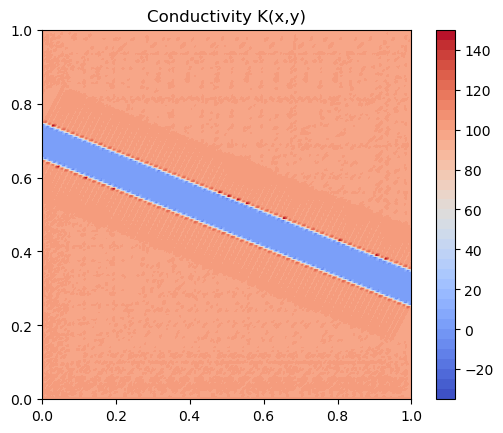

In [12]:
def plot_conductivity(parameters):
    K = get_conductivity(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="coolwarm")
    plt.colorbar(p)
    plt.title("Conductivity K(x,y)")

K_test = get_conductivity(example_parameters)
plot_conductivity(example_parameters)

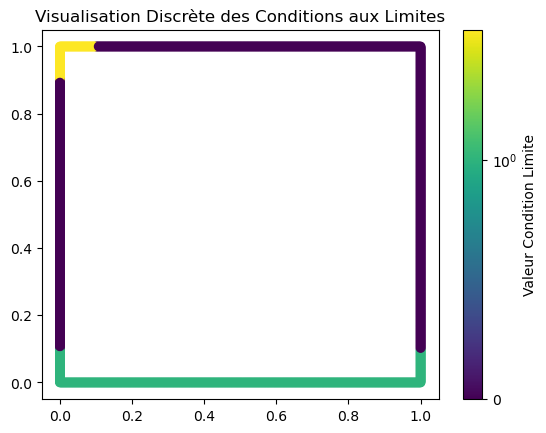

In [16]:

def plot_boundary_condition(cmap='viridis'):
    dof_coords = V.tabulate_dof_coordinates()
    boundary_dofs = bc.get_boundary_values().keys()
    x_b = np.array([dof_coords[dof][0] for dof in boundary_dofs])
    y_b = np.array([dof_coords[dof][1] for dof in boundary_dofs])
    v_b = np.array([u_L.vector()[dof] for dof in boundary_dofs])

    sc = plt.scatter(x_b, y_b, c=v_b, cmap=cmap, 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.colorbar(sc, label='Valeur Condition Limite')

plt.title("Visualisation Discrète des Conditions aux Limites")

plot_boundary_condition()

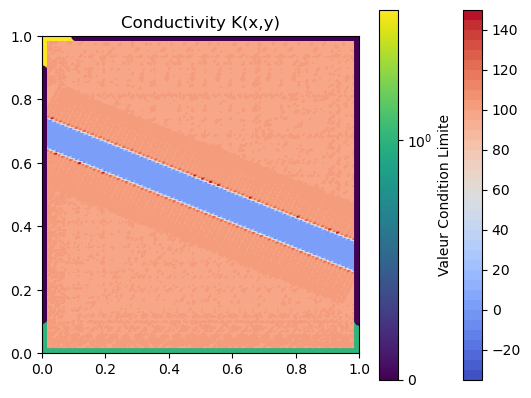

In [17]:
def plot_conductivity_boundary_condition(example_parameters):
    plot_conductivity(example_parameters)
    plot_boundary_condition() 
plot_conductivity_boundary_condition(example_parameters)

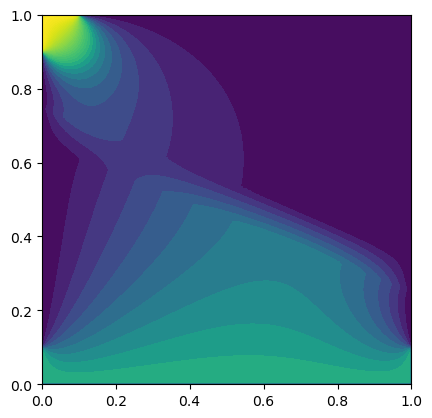

In [18]:

plot(uh_HDM_sol, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))

In [13]:
N_dof = V.dim()
Ns = 30
U_snapshot = np.zeros((N_dof, Ns))
print("dimension de U_snapshot:", U_snapshot.shape)

dimension de U_snapshot: (160801, 30)


In [20]:
parameters_list = []
for i in tqdm(range(Ns), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot[:, i] = uh_HDM_sol_vec
print(parameters_list)

Génération des Snapshots:   0%|          | 0/30 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   3%|▎         | 1/30 [00:05<02:37,  5.44s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   3%|▎         | 1/30 [00:07<03:37,  7.51s/it]


KeyboardInterrupt: 

In [14]:
def numpy_to_fenics(numpy_vec, V, u_L_vect):
    """
    Reconstruit un objet Function FEniCS à partir d'un vecteur Numpy.
    """
    # 1. On crée une "boîte" FEniCS vide sur ton maillage V
    u_reconstruit = Function(V)
    
    # 2. On fait l'opération inverse mathématiquement (- au lieu de +)
    valeurs_internes = numpy_vec - u_L_vect
    
    # 3. On injecte le tableau numpy dans le vecteur FEniCS (l'inverse de get_local)
    u_reconstruit.vector().set_local(valeurs_internes)
    
    return u_reconstruit

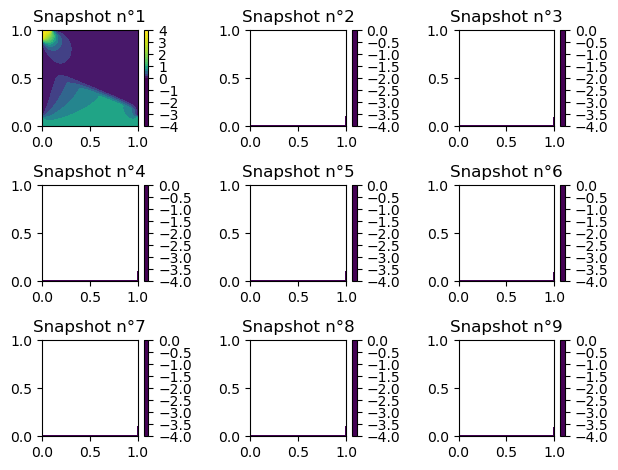

In [22]:
for i in range(9):
    vecteur_numpy = U_snapshot[:, i]    
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"Snapshot n°{i+1}")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [23]:
U, S, Vt = np.linalg.svd(U_snapshot, full_matrices=False)



number of singular values: 30
U shape: (160801, 30)
S shape: (30,)
Vt shape: (30, 30)
Singular values: [1.18217795e+03 1.16730570e+02 8.80793800e+01 4.90522754e+01
 4.56470003e+01 3.89194295e+01 2.92510529e+01 2.48942674e+01
 2.00719680e+01 1.72240948e+01 1.42456086e+01 1.15785018e+01
 9.48410313e+00 9.29840602e+00 7.64800928e+00 6.87313395e+00
 6.54607520e+00 5.43222064e+00 5.01944229e+00 4.23859878e+00
 3.69373032e+00 2.93320362e+00 2.79944722e+00 2.43738981e+00
 2.17795317e+00 2.12444559e+00 1.86264258e+00 1.77047754e+00
 1.31209703e+00 1.14596829e+00]


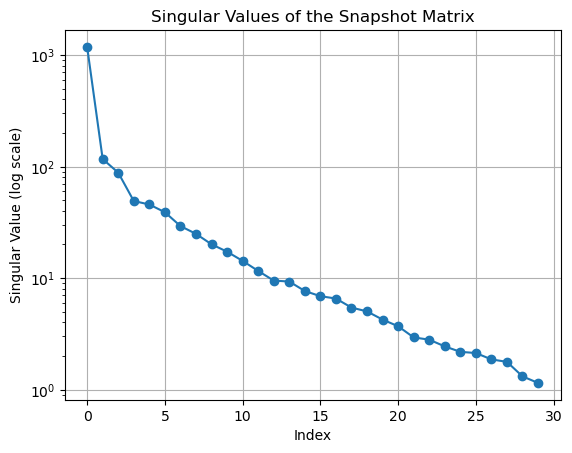

In [ ]:
print("number of singular values:", len(S))
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Singular values:", S)
plt.semilogy(S, marker='o')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

In [15]:
def plot_energy_contribution(S):
    energy = S**2
    cumulative_energy = np.cumsum(energy)
    total_energy = cumulative_energy[-1]
    energy_percentage = cumulative_energy / total_energy * 100
    print("Energy percentage:", energy_percentage)
    
    plt.figure(figsize=(8, 5))
    plt.plot(energy_percentage, marker='o')
    
    # --- LA CORRECTION EST ICI ---
    # On force l'axe Y à aller de 0 à 105% (ou 90 à 105% si tu préfères)
    plt.ylim(min(energy_percentage[0], 99), 100) 
    
    plt.xlabel('Number of Modes')
    plt.ylabel('Cumulative Energy (%)')
    plt.title('Cumulative Energy Contribution of Singular Values')
    plt.grid()
    plt.show()


Energy (squared singular values): [1.39754471e+06 1.36260259e+04 7.75797718e+03 2.40612573e+03
 2.08364864e+03 1.51472199e+03 8.55624097e+02 6.19724551e+02
 4.02883898e+02 2.96669442e+02 2.02937365e+02 1.34061703e+02
 8.99482121e+01 8.64603546e+01 5.84920459e+01 4.72399703e+01
 4.28511006e+01 2.95090211e+01 2.51948009e+01 1.79657196e+01
 1.36436437e+01 8.60368347e+00 7.83690475e+00 5.94086907e+00
 4.74348000e+00 4.51326907e+00 3.46943738e+00 3.13459072e+00
 1.72159861e+00 1.31324332e+00]
Cumulative energy: [1397544.70814997 1411170.73405223 1418928.71123392 1421334.83695997
 1423418.4855961  1424933.20758981 1425788.83168675 1426408.55623733
 1426811.44013583 1427108.10957781 1427311.04694316 1427445.10864619
 1427535.05685828 1427621.51721287 1427680.00925875 1427727.24922903
 1427770.1003296  1427799.6093507  1427824.80415161 1427842.76987121
 1427856.41351487 1427865.01719835 1427872.85410309 1427878.79497216
 1427883.53845216 1427888.05172123 1427891.52115861 1427894.65574933
 1427

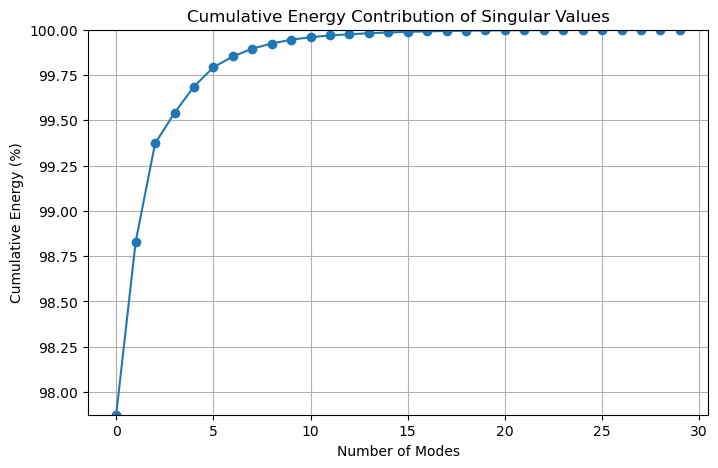

In [ ]:
plot_energy_contribution(S)

## Un premier test

Time for ROM solve: 0.26389193534851074 seconds
Time for full HDM solve: 1.7830886840820312 seconds


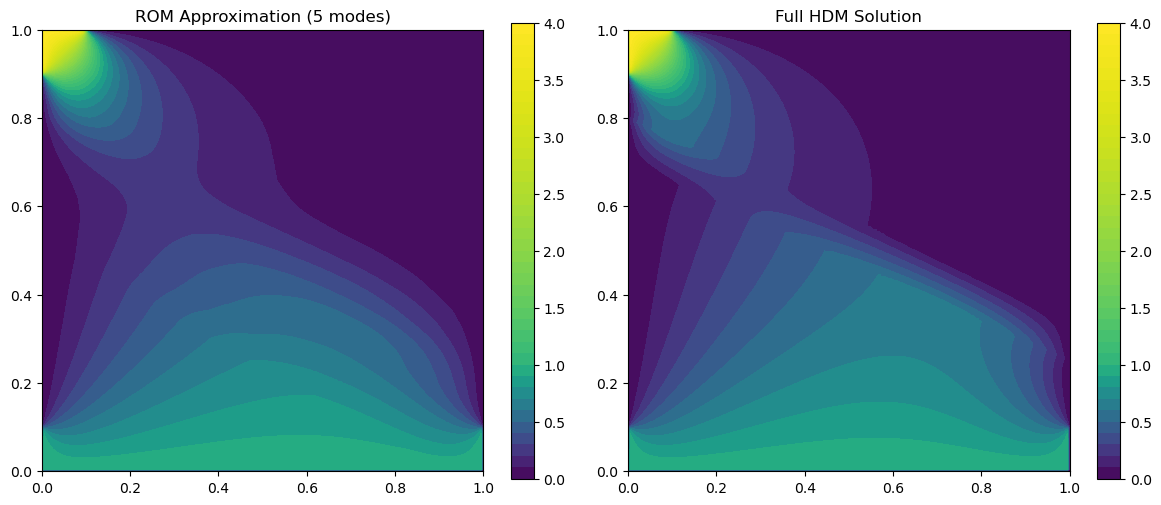

In [ ]:
test_parameters = {"slope": 45.0, "position": 75.0, "half_width": 5.0, "D_background": 100.0, "D_fracture": 1.0}
t = time()
A_test, b_test = get_stiffness_and_load(test_parameters)
V_r = U[:, :5]  # les 5 premiers modes
A_red = build_reduced_stiffness(A_test, V_r)
b_red = build_reduced_load(b_test, V_r)
u_red = np.linalg.solve(A_red, b_red)
u_approx = V_r.dot(u_red) + u_L_vect
u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
print("Time for ROM solve:", time() - t, "seconds")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
p1 = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.colorbar(p1)
plt.title("ROM Approximation (5 modes)")
plt.subplot(1, 2, 2)
t = time()
A_full, b_full = get_stiffness_and_load(test_parameters)
u_full = Function(V)
solve(A_full, u_full.vector(), b_full)
u_full_vec = np.array(u_full.vector().get_local()) + u_L_vect
u_full_fenics = numpy_to_fenics(u_full_vec, V, u_L_vect)
print("Time for full HDM solve:", time() - t, "seconds")
p2 = plot(u_full_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.colorbar(p2)
plt.title("Full HDM Solution")
plt.tight_layout()
plt.show()

## Qui est V1 ?

les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser


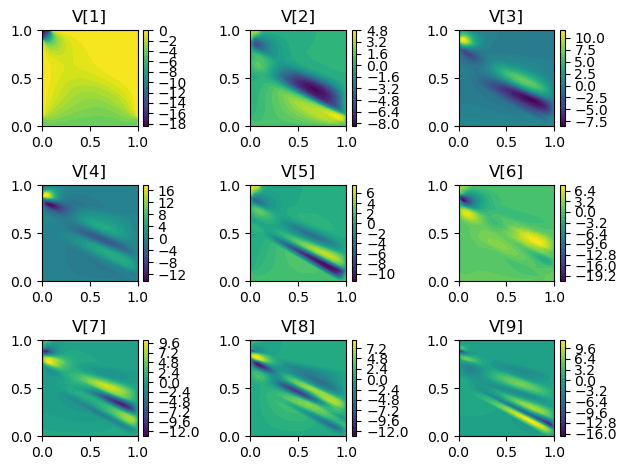

In [ ]:
print("les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser")
for i in range(9):
    vecteur_numpy = U[:, i]*1000
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"V[{i+1}]")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [16]:
def error_L2(u1, u2):
    """Calcule l'erreur relative L2 entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return norm(diff, 'L2') / norm(u1, 'L2')

Error with 1 modes: 1.0192e-01
Error with 2 modes: 9.5600e-02
Error with 3 modes: 8.4413e-02
Error with 4 modes: 7.5692e-02
Error with 5 modes: 8.4722e-02
Error with 6 modes: 8.0713e-02
Error with 7 modes: 6.0999e-02
Error with 8 modes: 4.7412e-02
Error with 9 modes: 4.4670e-02
Error with 10 modes: 4.1163e-02
Error with 11 modes: 4.0670e-02
Error with 12 modes: 3.9886e-02
Error with 13 modes: 3.8329e-02
Error with 14 modes: 3.7608e-02
Error with 15 modes: 3.7389e-02
Error with 16 modes: 3.7161e-02
Error with 17 modes: 3.7132e-02
Error with 18 modes: 3.7126e-02
Error with 19 modes: 3.7087e-02
Error with 20 modes: 3.7244e-02
Error with 21 modes: 3.7183e-02
Error with 22 modes: 3.7284e-02
Error with 23 modes: 3.7400e-02
Error with 24 modes: 3.7485e-02
Error with 25 modes: 3.6918e-02
Error with 26 modes: 3.6911e-02
Error with 27 modes: 3.6963e-02
Error with 28 modes: 3.6970e-02
Error with 29 modes: 3.6375e-02
Error with 30 modes: 3.6436e-02


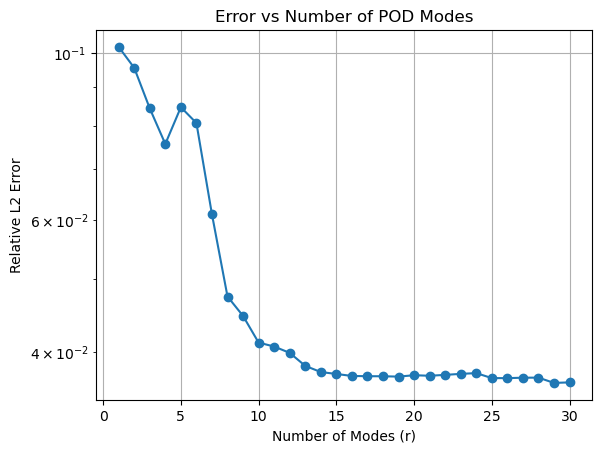

In [ ]:
error = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error[r-1] = error_L2(u_full_fenics, u_approx_fenics)
    print(f"Error with {r} modes: {error[r-1]:.4e}")
plt.figure()
plt.semilogy(range(1, 31), error, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative L2 Error')
plt.title('Error vs Number of POD Modes')
plt.grid()
plt.show()

In [18]:
def normeA(u, A):
    """Calcule la norme induite par A de la fonction u (version 100% FEniCS)."""
    # 1. On crée un vecteur FEniCS vide de la même taille que u
    Au = Vector(u.vector()) 
    
    # 2. FEniCS fait la multiplication Matrice * Vecteur (Au = A * u)
    A.mult(u.vector(), Au)
    
    # 3. FEniCS fait le produit scalaire u^T * (Au)
    norme_A = np.sqrt(u.vector().inner(Au)) 
    
    return norme_A
def error_A_norm(u1, u2, A):
    """Calcule l'erreur relative dans la norme induite par A entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return normeA(diff, A) / normeA(u1, A)

In [ ]:

error_A = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error_A[r-1] = error_A_norm(u_full_fenics, u_approx_fenics, A_test)
    print(f"Error in A-norm with {r} modes: {error_A[r-1]:.4e}")


plt.figure()
plt.semilogy(range(1, 31), error_A, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative Error in A-norm')
plt.title('Error in A-norm vs Number of POD Modes')
plt.grid()
plt.show()

NameError: name 'A_test' is not defined

## CAS LINÉAIRE

Si on ne fait varier que $D_{\text{back}}$ et $D_{\text{fract}}$ dans la formule de $D_\mu(x, y)$ :

$D_\mu(x, y) = D_{\text{back}} \cdot \left( \sigma(-ax - y + (x_0 - w)) + \sigma(ax + y - (x_0 + w)) \right) + D_{\text{fract}} \cdot \sigma(-ax - y + (x_0 - w)) \cdot \sigma(ax + y - (x_0 + w))$

On se rend compte que la dépendance en les paramettre est linaire ainsi la matrice $A$ du probleme peut etre construit comme tel :

$\mathbf{A} = D_{\text{frac}} \cdot \mathbf{A}_{\text{frac}} + D_{\text{back}} \cdot \mathbf{A}_{\text{back}}$

Où $\mathbf{A}_{\text{frac}}$ et $\mathbf{A}_{\text{back}}$ ne sont calculées que une fois.


In [ ]:
Ns_lineaire = 50
U_snapshot_lineaire = np.zeros((N_dof, Ns_lineaire))
print("dimension de U_snapshot:", U_snapshot_lineaire.shape)

dimension de U_snapshot: (160801, 50)


In [ ]:
parameters_list_lineaire = []
for i in tqdm(range(Ns_lineaire), desc="Génération des Snapshots"):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list_lineaire.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_lineaire[:, i] = uh_HDM_sol_vec
print(parameters_list_lineaire)

Génération des Snapshots:   0%|          | 0/50 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   2%|▏         | 1/50 [00:04<03:55,  4.81s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   4%|▍         | 2/50 [00:09<03:37,  4.52s/it]

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  98%|█████████▊| 49/50 [03:16<00:03,  3.90s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots: 100%|██████████| 50/50 [03:20<00:00,  4.02s/it]

[{'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 84.89758618679146, 'D_fracture': 1.5634433320291545}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 86.88642833232338, 'D_fracture': 1.3109383516175415}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 83.75691804309542, 'D_fracture': 0.921553119349772}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 88.00414466020781, 'D_fracture': 1.3790086073139352}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 96.56576489988728, 'D_fracture': 1.6753206674857495}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 112.72733941027957, 'D_fracture': 0.8977271249656602}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 94.3281320404487, 'D_fracture': 1.385271794344587}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 85.86183729307035, 'D_fracture': 0.5912339912153001}, {'slope': 40.0, '

In [ ]:
U_l, S_l, Vt_l = np.linalg.svd(U_snapshot_lineaire, full_matrices=False)

number of singular values: 50
U shape: (160801, 50)
S shape: (50,)
Vt shape: (50, 50)
Singular values: [1.54505237e+03 6.78911787e+00 3.82578812e-02 3.97664248e-03
 2.91941730e-05 2.82080797e-06 3.68026088e-08 1.82616290e-09
 6.12913539e-10 3.19020595e-11 2.64869455e-11 1.93420197e-11
 1.39173273e-11 1.12702217e-11 6.23046804e-12 5.01610974e-12
 3.81939887e-12 2.89428757e-12 2.10514007e-12 1.94058388e-12
 1.62337378e-12 1.37228218e-12 1.27810068e-12 1.20151893e-12
 1.14749412e-12 1.01344663e-12 8.88099931e-13 8.13390876e-13
 7.40251380e-13 6.26776279e-13 6.21039219e-13 5.85282385e-13
 5.58373775e-13 5.12817832e-13 5.02672855e-13 4.72644958e-13
 4.25868732e-13 3.47402935e-13 3.42331646e-13 3.34248273e-13
 3.17436205e-13 3.15169325e-13 3.01465015e-13 2.96750660e-13
 2.67103052e-13 2.61346462e-13 2.49111684e-13 2.47397459e-13
 2.20964846e-13 1.99359125e-13]


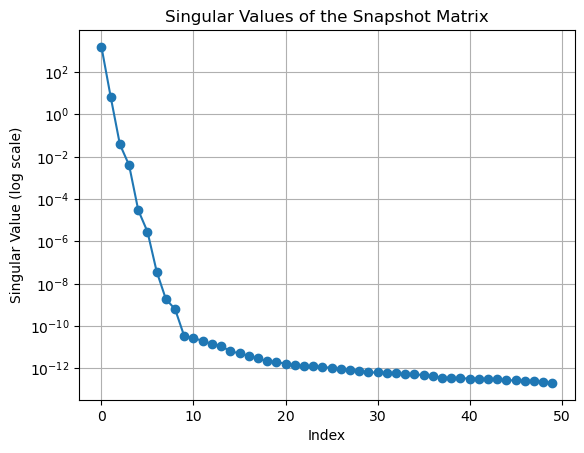

In [ ]:
print("number of singular values:", len(S_l))
print("U shape:", U_l.shape)
print("S shape:", S_l.shape)
print("Vt shape:", Vt_l.shape)
print("Singular values:", S_l)
plt.semilogy(S_l, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

Energy (squared singular values): [2.38718684e+06 4.60921214e+01 1.46366547e-03 1.58136854e-05
 8.52299739e-10 7.95695763e-12 1.35443202e-15 3.33487094e-18
 3.75663006e-19 1.01774140e-21 7.01558283e-22 3.74113726e-22
 1.93692000e-22 1.27017898e-22 3.88187320e-23 2.51613570e-23
 1.45878077e-23 8.37690055e-24 4.43161473e-24 3.76586578e-24
 2.63534244e-24 1.88315837e-24 1.63354134e-24 1.44364774e-24
 1.31674276e-24 1.02707407e-24 7.88721488e-25 6.61604716e-25
 5.47972105e-25 3.92848503e-25 3.85689711e-25 3.42555470e-25
 3.11781272e-25 2.62982129e-25 2.52679999e-25 2.23393256e-25
 1.81364177e-25 1.20688799e-25 1.17190956e-25 1.11721908e-25
 1.00765744e-25 9.93317037e-26 9.08811551e-26 8.80609542e-26
 7.13440406e-26 6.83019730e-26 6.20566310e-26 6.12055025e-26
 4.88254631e-26 3.97440606e-26]
Cumulative energy: [2387186.83838966 2387232.93051107 2387232.93197473 2387232.93199055
 2387232.93199055 2387232.93199055 2387232.93199055 2387232.93199055
 2387232.93199055 2387232.93199055 2387232.93

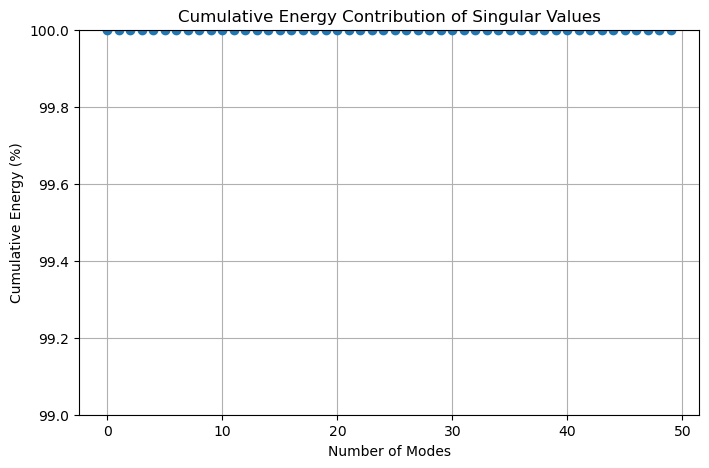

In [ ]:
plot_energy_contribution(S_l)

In [42]:
N_test = 10
parameters_test_lineaire_list = []
for i in range(N_test):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_test_lineaire_list.append(parameters)

In [ ]:
Ns_lineaire_range = [1, 3, 6, 9, 20, 50, 100]#range(1, Ns_lineaire+1, 10)
error_A_lineaire = np.zeros(len(Ns_lineaire_range))
time_linear = np.zeros(len(Ns_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_l[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_linear_list = []
b_test_linear_list = []
HF_sol_linear_list = []
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_linear_list.append(A_test)
    b_test_linear_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_linear_list.append(u_full)




for j, r in enumerate(tqdm(Ns_lineaire_range, desc="Testing ROM with linear snapshots")):
    for i, params in enumerate(parameters_test_lineaire_list):

        u_full = HF_sol_linear_list[i]
        V_r = U_l[:, :r]

        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 
        A_test, b_test = get_stiffness_and_load(params)
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_lineaire[j] /= len(parameters_test_lineaire_list) 
    time_linear[j] /= len(parameters_test_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_lineaire[j]:.4e} | Time: {time_linear[j]:.4e} s")


Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.
Tour de chauffe terminé ! Lancement du benchmark...
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time

Testing ROM with linear snapshots:  14%|█▍        | 1/7 [00:01<00:11,  1.84s/it]

Error in A-norm with 1 modes: 2.6925e-04 | Time: 1.7096e-01 s


Testing ROM with linear snapshots:  29%|██▊       | 2/7 [00:03<00:09,  1.84s/it]

...

Error in A-norm with 20 modes: 4.6028e-14 | Time: 2.1031e-01 s


Testing ROM with linear snapshots:  86%|████████▌ | 6/7 [00:19<00:04,  4.71s/it]

Error in A-norm with 50 modes: 5.4921e-14 | Time: 9.8089e-01 s


Testing ROM with linear snapshots: 100%|██████████| 7/7 [00:31<00:00,  4.50s/it]

Error in A-norm with 100 modes: 5.4921e-14 | Time: 1.1669e+00 s


In [43]:
HF_compution_time = 0
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    u_full = Function(V)
    t = time()
    solve(A_test, u_full.vector(), b_test)
    HF_compution_time += time() - t
HF_compution_time /= N_test
print(f"Average time for HF computation: {HF_compution_time:.4f} seconds")


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FF

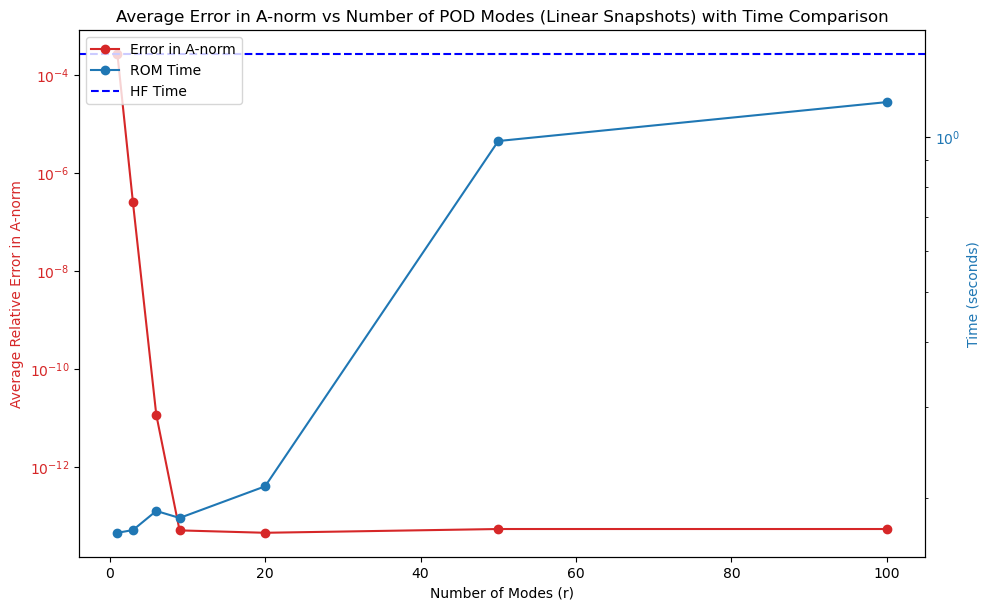

In [ ]:

# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(Ns_lineaire_range, time_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()


évolution de la solution approchée en fonction du nombre de modes POD :


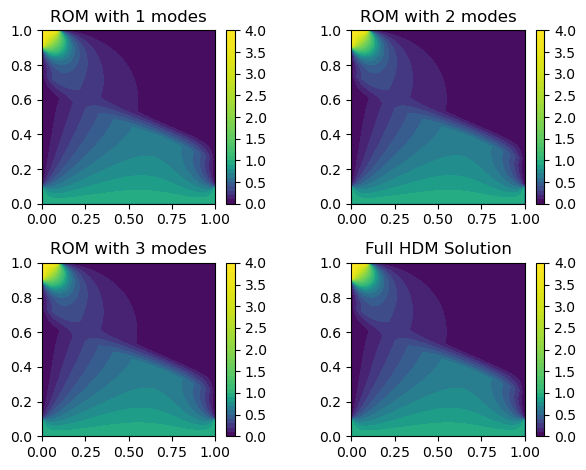

In [ ]:
print("évolution de la solution approchée en fonction du nombre de modes POD :")
for r in range(3):
    V_r = U_l[:, :r+1]
    A_test = A_test_linear_list[0]  # On prend le premier cas de test pour la visualisation
    b_test = b_test_linear_list[0]  # On prend le premier cas de test pour la visualisation
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    
    plt.subplot(2, 2, r + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {r+1} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(2, 2, 4)
u_full = HF_sol_linear_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Maintenant essayions de chercher $\mathbf{A}_{\text{frac}}$ et $\mathbf{A}_{\text{back}}$

In [ ]:
p_f = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 0, "D_fracture": 1.0}
p_b = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 1.0, "D_fracture": 0}
A_frac, b_frac = get_stiffness_and_load(p_f)
A_back, b_back = get_stiffness_and_load(p_b)

In [ ]:
error_A_lineaire_sep = np.zeros(len(Ns_lineaire_range))
time_linear_sep = np.zeros(len(Ns_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_l[:, :r_max]
A_frac_red_warmup = build_reduced_stiffness(A_frac, V_r_warmup) # Chauffe la projection
b_frac_red_warmup = build_reduced_load(b_frac, V_r_warmup)
A_back_red_warmup = build_reduced_stiffness(A_back, V_r_warmup)
b_back_red_warmup = build_reduced_load(b_back, V_r_warmup)
A_red_warmup = p_b["D_background"] * A_back_red_warmup + p_f["D_fracture"] * A_frac_red_warmup
b_red_warmup = p_b["D_background"] * b_back_red_warmup + p_f["D_fracture"] * b_frac_red_warmup
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_linear_list = []
b_test_linear_list = []
HF_sol_linear_list = []
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_linear_list.append(A_test)
    b_test_linear_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_linear_list.append(u_full)




for j, r in enumerate(tqdm(Ns_lineaire_range, desc="Testing ROM with linear snapshots")):
    for i, params in enumerate(parameters_test_lineaire_list):
        A_test = A_test_linear_list[i]#pour la norme A
        u_full = HF_sol_linear_list[i]
        V_r = U_l[:, :r]
        A_frac_red = build_reduced_stiffness(A_frac, V_r)
        b_frac_red = build_reduced_load(b_frac, V_r)
        A_back_red = build_reduced_stiffness(A_back, V_r)
        b_back_red = build_reduced_load(b_back, V_r)
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 

        A_red = params["D_background"] * A_back_red + params["D_fracture"] * A_frac_red
        b_red = params["D_background"] * b_back_red + params["D_fracture"] * b_frac_red
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_lineaire_sep[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_linear_sep[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_lineaire_sep[j] /= len(parameters_test_lineaire_list) 
    time_linear_sep[j] /= len(parameters_test_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_lineaire_sep[j]:.4e} | Time: {time_linear_sep[j]:.4e} s")

Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Tour de chauffe terminé ! Lancement du benchmark...


Testing ROM with linear snapshots:  14%|█▍        | 1/7 [00:00<00:02,  2.90it/s]

Error in A-norm with 1 modes: 2.6925e-04 | Time: 3.6976e-04 s


Testing ROM with linear snapshots:  29%|██▊       | 2/7 [00:00<00:02,  2.12it/s]

Error in A-norm with 3 modes: 2.5160e-07 | Time: 4.8778e-03 s


...

Error in A-norm with 20 modes: 8.8506e-14 | Time: 2.0660e-03 s


Testing ROM with linear snapshots:  86%|████████▌ | 6/7 [00:21<00:06,  6.57s/it]

Error in A-norm with 50 modes: 8.6628e-14 | Time: 1.7594e-03 s


Testing ROM with linear snapshots: 100%|██████████| 7/7 [00:40<00:00,  5.81s/it]

Error in A-norm with 100 modes: 8.6628e-14 | Time: 1.8137e-03 s


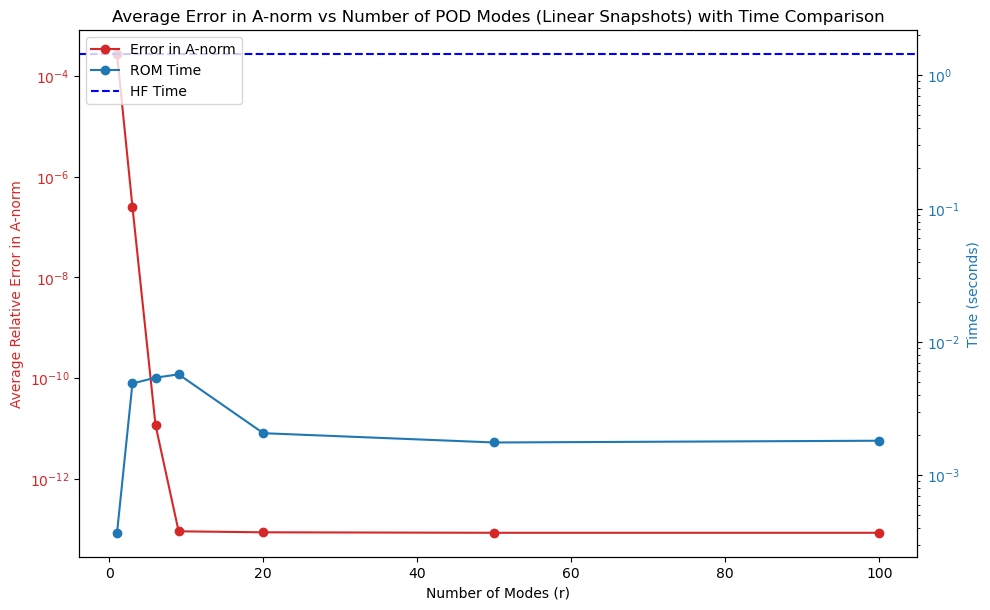

In [ ]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire_sep, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(Ns_lineaire_range, time_linear_sep, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

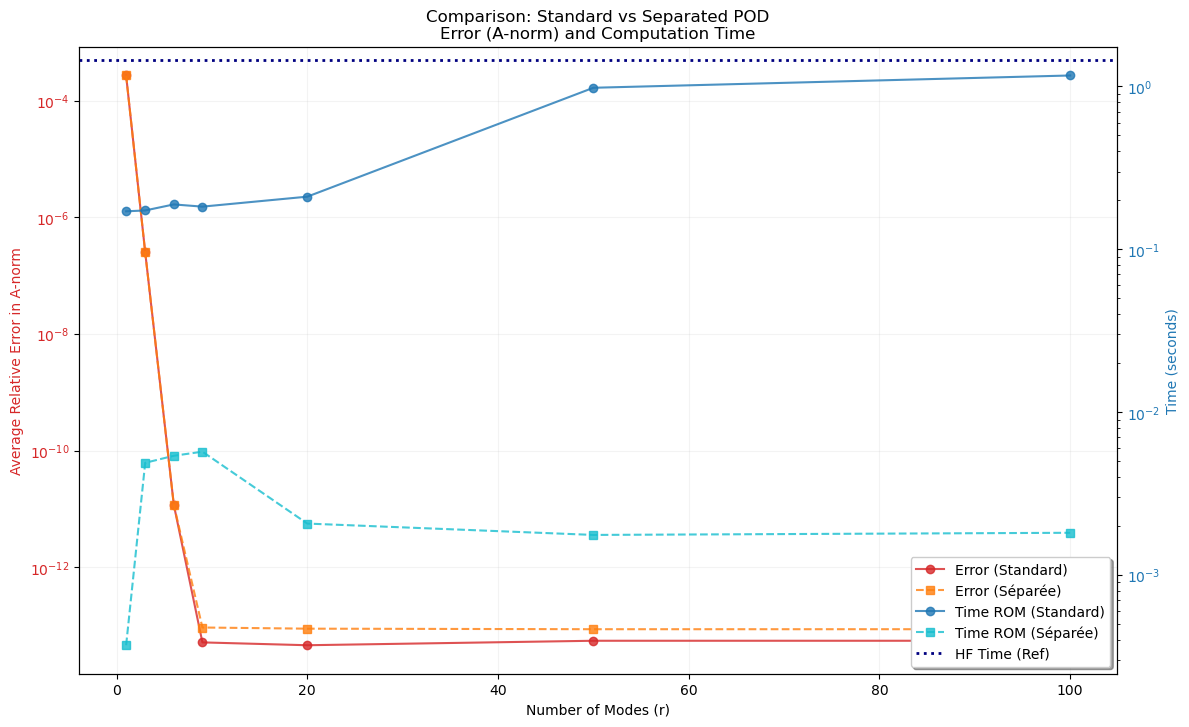

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- AXE GAUCHE : ERREURS ---
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color='tab:red')

# Erreur "Standard"
ax1.semilogy(Ns_lineaire_range, error_A_lineaire, 
             marker='o', color='tab:red', linestyle='-', alpha=0.8, label='Error (Standard)')
# Erreur "Séparée" (_sep)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire_sep, 
             marker='s', color='tab:orange', linestyle='--', alpha=0.8, label='Error (Séparée)')

ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, which="both", ls="-", alpha=0.15)

# --- AXE DROITE : TEMPS ---
ax2 = ax1.twinx()
ax2.set_ylabel('Time (seconds)', color='tab:blue')

# Temps ROM "Standard"
ax2.semilogy(Ns_lineaire_range, time_linear, 
             marker='o', color='tab:blue', linestyle='-', alpha=0.8, label='Time ROM (Standard)')
# Temps ROM "Séparé" (_sep)
ax2.semilogy(Ns_lineaire_range, time_linear_sep, 
             marker='s', color='tab:cyan', linestyle='--', alpha=0.8, label='Time ROM (Séparée)')

# Temps Haute Fidélité (Référence horizontale)
ax2.axhline(y=HF_compution_time, color='navy', linestyle=':', linewidth=2, label='HF Time (Ref)')

ax2.tick_params(axis='y', labelcolor='tab:blue')

# --- LÉGENDE ET FINITIONS ---
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# On place la légende à l'endroit le plus vide (souvent center right ou upper right)
ax2.legend(lines1 + lines2, labels1 + labels2, loc='best', frameon=True, shadow=True)

plt.title('Comparison: Standard vs Separated POD\nError (A-norm) and Computation Time')
plt.show()

## CAS NON-LINÉAIRE

Maintenant faisons varier $a$, $w$ et $x_0$ plutot que $D_{\text{back}}$ et $D_{\text{fract}}$ dans la formule de $D_\mu(x, y)$ :

$D_\mu(x, y) = D_{\text{back}} \cdot \left( \sigma(-ax - y + (x_0 - w)) + \sigma(ax + y - (x_0 + w)) \right) + D_{\text{fract}} \cdot \sigma(-ax - y + (x_0 - w)) \cdot \sigma(ax + y - (x_0 + w))$

Cette fois-ci la dépendance n'est absolument pas lineaire.


In [24]:
Ns_non_lineaire = 200
U_snapshot_non_lineaire = np.zeros((N_dof, Ns_non_lineaire))
print("dimension de U_snapshot:", U_snapshot_non_lineaire.shape)

dimension de U_snapshot: (160801, 200)


In [1]:
parameters_list_non_lineaire = []
for i in tqdm(range(Ns_non_lineaire), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = 100.0
    D_fracture = 1.0

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list_non_lineaire.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_non_lineaire[:, i] = uh_HDM_sol_vec
print(parameters_list_non_lineaire)

NameError: name 'tqdm' is not defined

In [32]:
U_nl, S_nl, Vt_nl = np.linalg.svd(U_snapshot_non_lineaire, full_matrices=False)

In [33]:
print(U_nl.shape)

(160801, 200)


number of singular values: 200
U shape: (160801, 200)
S shape: (200,)
Vt shape: (200, 200)
Singular values: [3.03493998e+03 3.20479290e+02 2.63597322e+02 1.58040098e+02
 1.17817750e+02 9.76470540e+01 7.89155588e+01 6.26936242e+01
 5.67229922e+01 4.89126864e+01 4.37849349e+01 3.62490895e+01
 3.24874893e+01 2.99872990e+01 2.78152073e+01 2.63016800e+01
 2.25371815e+01 2.20385831e+01 1.95879553e+01 1.72092131e+01
 1.66543096e+01 1.44514904e+01 1.32819422e+01 1.30494191e+01
 1.21163422e+01 1.06659045e+01 1.00725153e+01 9.90388351e+00
 9.06123684e+00 8.97974633e+00 7.98307202e+00 7.87666130e+00
 7.77363352e+00 7.22215744e+00 7.05864668e+00 6.65882194e+00
 6.28892136e+00 6.14439806e+00 5.89064266e+00 5.45297630e+00
 5.34422883e+00 5.21677313e+00 4.89364651e+00 4.78473197e+00
 4.67611468e+00 4.51746981e+00 4.43136182e+00 4.34236104e+00
 4.18396931e+00 4.13377298e+00 3.97405541e+00 3.78719795e+00
 3.67449772e+00 3.66977977e+00 3.60883151e+00 3.40426548e+00
 3.30050026e+00 3.25489610e+00 3.22215

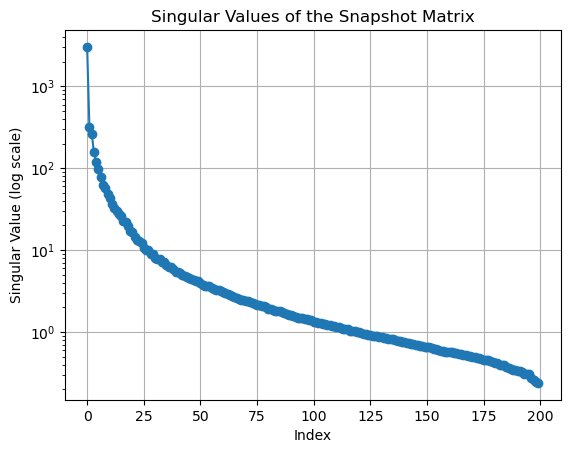

In [34]:
print("number of singular values:", len(S_nl))
print("U shape:", U_nl.shape)
print("S shape:", S_nl.shape)
print("Vt shape:", Vt_nl.shape)
print("Singular values:", S_nl)
plt.semilogy(S_nl, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

Energy percentage: [ 97.38652872  98.47245067  99.20710096  99.47117959  99.61794378
  99.71875688  99.78460205  99.82615917  99.86017781  99.88547322
  99.90574296  99.91963586  99.930795    99.94030266  99.94848284
  99.95579702  99.96116732  99.96630262  99.97035936  99.97349063
  99.97642322  99.97863135  99.98049653  99.98229698  99.98384916
  99.98505196  99.98612465  99.98716173  99.98802983  99.9888824
  99.98955621  99.99021218  99.9908511   99.99140258  99.99192938
  99.99239818  99.99281635  99.99321552  99.9935824   99.99389679
  99.99419876  99.9944865   99.9947397   99.99498176  99.99521295
  99.99542872  99.99563634  99.99583571  99.99602079  99.99620147
  99.99636845  99.99652009  99.99666285  99.99680524  99.99694294
  99.99706547  99.99718064  99.99729266  99.99740243  99.99750542
  99.99760467  99.9976988   99.99779009  99.9978762   99.99795758
  99.99803223  99.99810358  99.99817202  99.99823667  99.99829965
  99.99835963  99.9984185   99.99847467  99.99852747  99.9

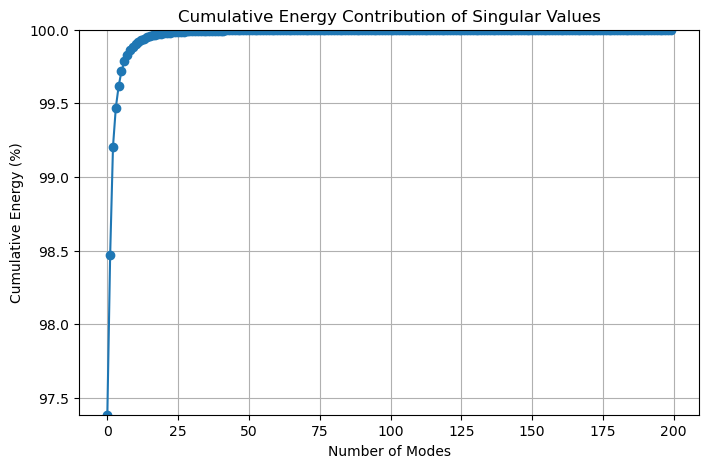

In [173]:
plot_energy_contribution(S_nl)

In [36]:
N_test = 10
parameters_test_non_lineaire_list = []
for i in range(N_test):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = 100.0
    D_fracture = 1.0
    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_test_non_lineaire_list.append(parameters)

In [106]:
Ns_non_lineaire_range = range(0, Ns_non_lineaire+1, 10)
error_A_non_lineaire = np.zeros(len(Ns_non_lineaire_range))
error_L2_non_lineaire = np.zeros(len(Ns_non_lineaire_range))
time_non_linear = np.zeros(len(Ns_non_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_non_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_non_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_nl[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_list = []
b_test_list = []
HF_sol_list = []
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_list.append(A_test)
    b_test_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list.append(u_full)




for j, r in enumerate(tqdm(Ns_non_lineaire_range, desc="Testing ROM with non-linear snapshots")):
    for i, params in enumerate(parameters_test_non_lineaire_list):
        A_test = A_test_list[i]
        b_test = b_test_list[i]
        u_full = HF_sol_list[i]
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 

        V_r = U_nl[:, :r]
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_non_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        error_L2_non_lineaire[j] += error_L2(u_full, u_approx_fenics)
        time_non_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_non_lineaire[j] /= len(parameters_test_non_lineaire_list) 
    error_L2_non_lineaire[j] /= len(parameters_test_non_lineaire_list)
    time_non_linear[j] /= len(parameters_test_non_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_non_lineaire[j]:.4e} | Error in L2-norm: {error_L2_non_lineaire[j]:.4e}     | Time: {time_non_linear[j]:.4e} s")

Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Tour de chauffe terminé ! Lancement du benchmark...


Testing ROM with non-linear snapshots:   5%|▍         | 1/21 [00:00<00:07,  2.82it/s]

Error in A-norm with 0 modes: 1.0000e+00 | Error in L2-norm: 1.0000e+00     | Time: 7.8134e-03 s


Testing ROM with non-linear snapshots:  10%|▉         | 2/21 [00:01<00:11,  1.67it/s]

Error in A-norm with 10 modes: 1.3745e-02 | Error in L2-norm: 8.2254e-02     | Time: 4.8118e-02 s


...

Error in A-norm with 180 modes: 5.4720e-03 | Error in L2-norm: 2.8977e-02     | Time: 3.2910e+00 s


Testing ROM with non-linear snapshots:  95%|█████████▌| 20/21 [06:16<00:29, 29.70s/it]

Error in A-norm with 190 modes: 5.4363e-03 | Error in L2-norm: 2.9002e-02     | Time: 2.8792e+00 s


Testing ROM with non-linear snapshots: 100%|██████████| 21/21 [06:41<00:00, 19.13s/it]

Error in A-norm with 200 modes: 5.4055e-03 | Error in L2-norm: 2.8960e-02     | Time: 2.5011e+00 s


In [38]:
HF_compution_time_nl = 0
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    u_full = Function(V)
    t = time()
    solve(A_test, u_full.vector(), b_test)
    HF_compution_time_nl += time() - t
HF_compution_time_nl /= N_test
print(f"Average time for HF computation: {HF_compution_time_nl:.4f} seconds")

Average time for HF computation: 1.0263 seconds


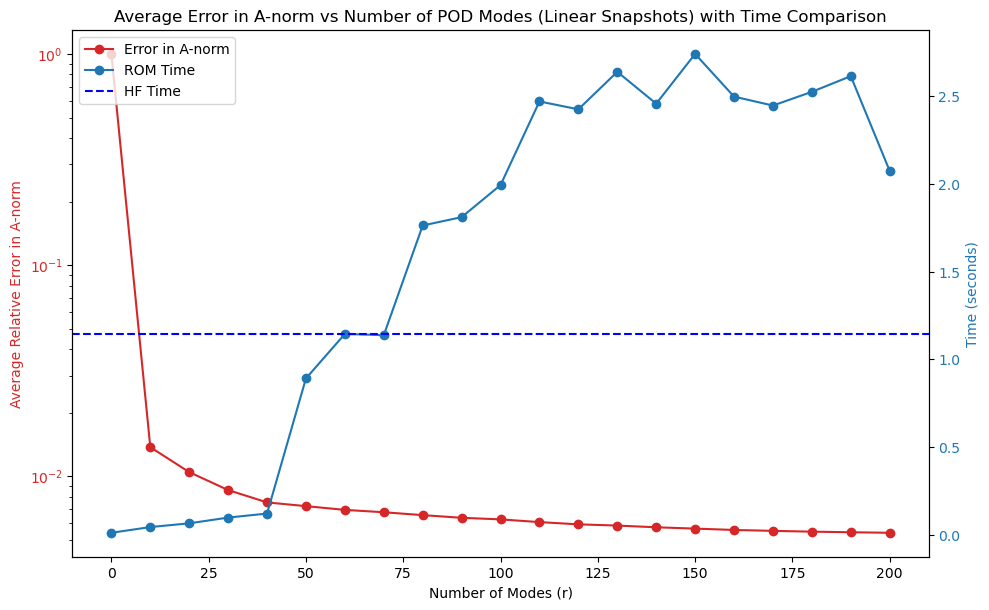

In [ ]:

# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_non_lineaire_range, error_A_non_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

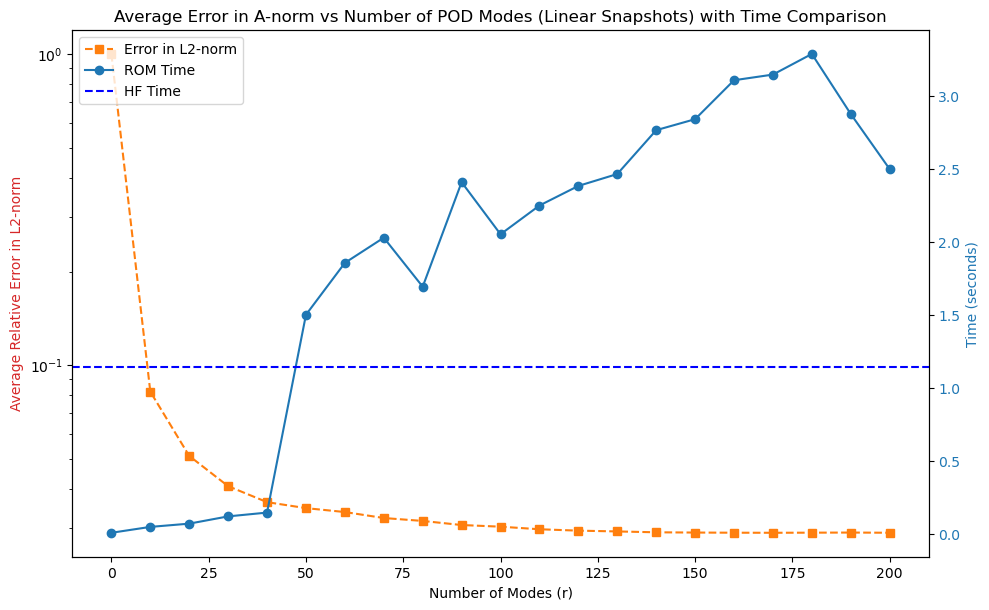

In [108]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in L2-norm', color=color)

# Plotter l'erreur en norme L2 sur l'axe principal (gauche)
color = 'tab:orange'
ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='s', color=color, linestyle='--', label='Error in L2-norm')
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

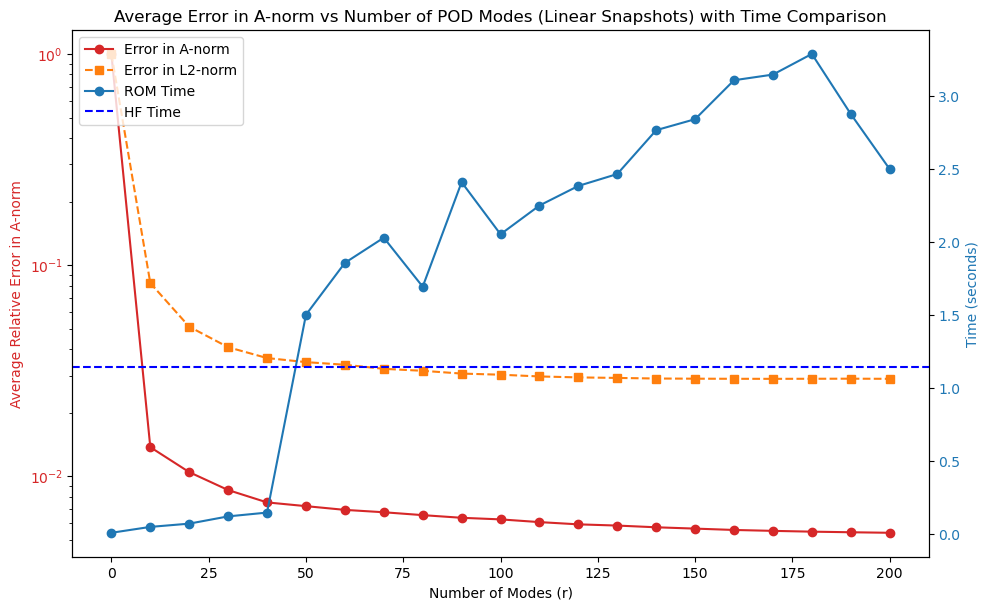

In [107]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_non_lineaire_range, error_A_non_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Plotter l'erreur en norme L2 sur l'axe principal (gauche)
color = 'tab:orange'
ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='s', color=color, linestyle='--', label='Error in L2-norm')
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

évolution de la solution approchée en fonction du nombre de modes POD :


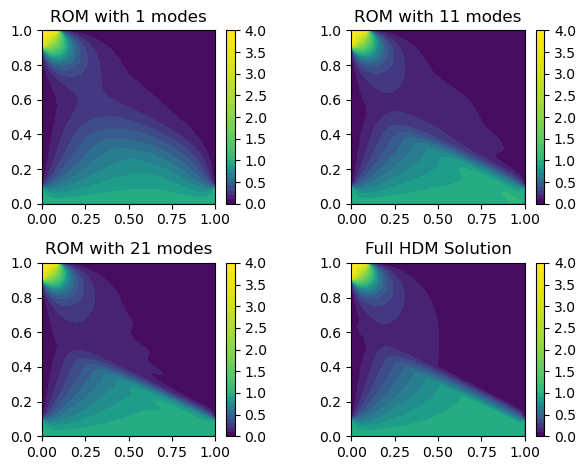

In [45]:
print("évolution de la solution approchée en fonction du nombre de modes POD :")
for i, r in enumerate(range(1, 31, 10)):
    V_r = U_nl[:, :r]
    A_test = A_test_list[0]  # On prend le premier cas de test pour la visualisation
    b_test = b_test_list[0]  # On prend le premier cas de test pour la visualisation
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    
    plt.subplot(2, 2, i + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {r} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(2, 2, 4)
u_full = HF_sol_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## L'EIM
Nous sommes donnés une fonction $g(·;µ) \in L∞(Ω)$ de régularité suffisante. 

Pour commencer, nous choisissons $\mu_g^1$, et définissons $S_g^1 = \{\mu_g^1\}$, $\xi_1 ≡ g(x;\mu_g^1)$, et $W_g^1 = \text{span}\{\xi_1\}$ ; nous supposons que $\xi_1 ≠ 0$. 

Ensuite, pour $M ≥ 2$, nous définissons $\mu_g^M = \arg \max_{\mu \in \Xi_g} \inf_{z \in W_g^{M-1}} \|g(·;\mu)− z\|_{L∞(Ω)}$, où $\Xi_g$ est un échantillon de paramètre suffisamment fin sur $D$. 

Nous définissons ensuite $S_g^M = S_g^{M-1} ∪ \mu_g^M$, $\xi_M = g(x;\mu_g^M)$, et $W_g^M = \text{span}\{\xi_m, 1 ≤ m ≤ M\}$ . 

Notez que, grâce à notre approximation de vérité, $\mu_g^M$ est la solution d'un programme linéaire standard.



In [46]:
def g(mu):
    """
    Accepte mu sous forme de dictionnaire ou de liste/array.
    """
    if isinstance(mu, dict):
        # Si c'est déjà un dictionnaire, on l'utilise tel quel
        parameters = mu
    else:
        # Si c'est une liste, on la convertit
        parameters = {
            "slope": mu[0], 
            "position": mu[1], 
            "half_width": mu[2], 
            "D_background": mu[3], 
            "D_fracture": mu[4]
        }
        
    K = get_conductivity(parameters)
    return project(K, V)


M_max = 40

MU_MIN = [
    20.0,
    50.0,
    3.0
]

# --- BORNES SUPÉRIEURES (MAX) ---
MU_MAX = [
    60.0,
    90.0,
    7.0
]



In [47]:


# Générer des points aléatoires
RandomPoints = np.random.rand(400, 3) * (np.array(MU_MAX) - np.array(MU_MIN)) + np.array(MU_MIN)

# Transformer les points en une liste de listes exploitables par vos fonctions
D_train = [
    [s, p, hw, 100.0, 1.0]
    for s, p, hw in RandomPoints
]

print(f"Taille de l'espace d'entraînement D_train : {len(D_train)} points")


Taille de l'espace d'entraînement D_train : 400 points


In [48]:
from joblib import Parallel, delayed

def compute_single_snapshot(mu):
    # On appelle ta fonction g(mu)
    # L'avantage du threading est qu'il accède directement à 'V' et 'g' sans copie
    G = g(mu)
    return G.vector().get_local()

# --- CONFIGURATION ---
N_train = len(D_train)
print(f"Création de la Matrice : {N_train} paramètres.")

# Lancement avec le backend 'threading' pour éviter l'erreur de Pickle
results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(compute_single_snapshot)(mu) for mu in tqdm(D_train, desc="Phase Offline Parallèle")
)

Snapshots_conductivite = np.array(results)
print(f"\nTerminé ! Forme de la matrice : {Snapshots_conductivite.shape}")

Création de la Matrice : 400 paramètres.


Phase Offline Parallèle:   0%|          | 0/400 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Phase Offline Parallèle:   6%|▌         | 22/400 [00:04<01:15,  5.03it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Phase Offline Parallèle:  96%|█████████▋| 385/400 [13:44<00:33,  2.26s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Phase Offline Parallèle: 100%|██████████| 400/400 [14:08<00:00,  2.12s/it]


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.

Terminé ! Forme de la matrice : (400, 160801)


ensuite :
$\mu_g^M = \arg \max_{\mu \in \Xi_g} \inf_{z \in W_g^{M-1}} \|g(·;\mu)− z\|_{L∞(Ω)}$


In [50]:
U_EIM, S_EIM, Vt_EIM = np.linalg.svd(Snapshots_conductivite, full_matrices=False)

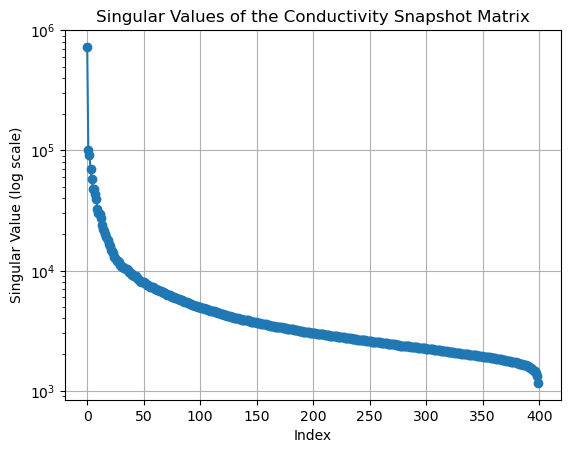

In [52]:
plt.semilogy(S_EIM, marker='o', label='Singular Values (Conductivity Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Conductivity Snapshot Matrix')
plt.grid()
plt.show()

In [ ]:
# =======================================================
    # 1. ÉTAPE GREEDY : Recherche du pire paramètre
    # =======================================================
    if m == 0:
        # Initialisation : on prend le max absolu parmi tous les snapshots
        norms = np.max(np.abs(Snapshots_conductivite), axis=1)
        best_idx = np.argmax(norms)
        err_max = norms[best_idx]
    else:
        err_max = -1.0
        best_idx = -1
        
        # On utilise notre belle matrice B pré-calculée
        B_current = B_complet[:m, :m]
        T_current = Magic_Points[:m]
        
        for i in range(N_train):
            g_test = Snapshots_conductivite[i]
            
            # --- C'est ici que se fait la "projection" instantanée ! ---
            g_magic = g_test[T_current]
            beta = np.linalg.solve(B_current, g_magic)
            g_interp = beta @ Q[:m, :]
            
            # Calcul de l'erreur L-infini
            err = np.max(np.abs(g_test - g_interp))
            # -----------------------------------------------------------
            
            if err > err_max:
                err_max = err
                best_idx = i


In [53]:
# --- INITIALISATION ---
M_max = 400  # Nombre de modes EIM souhaités
N_train = len(D_train)
nb_dofs = V.dim()

Q = np.zeros((M_max, nb_dofs))     # Base de fonctions q_m (normalisées)
Magic_Points = []                  # Ensemble des t_m (les indices)
S_mu = []                          # Paramètres sélectionnés

# Ps on remarque que les coeffs de l'articles B_ij^M sont indépendant de M donc on peut faire que une matrice 
B_complet = np.zeros((M_max, M_max))
print("Lancement de l'algorithme DEIM (SVD + Magic Points)...")

for m in tqdm(range(M_max), desc="Construction de la base DEIM"):
    
    # =======================================================
    # 1. SÉLECTION DU MODE (Fini le Greedy, merci la SVD !)
    # =======================================================
    # Le m-ième mode spatial dominant est simplement la m-ième ligne de Vt_EIM
    xi_M = Vt_EIM[m, :]

    # =======================================================
    # 2. CONSTRUCTION DU NOUVEAU MODE EIM/DEIM
    # =======================================================
    if m == 0:
        # Premier mode
        t_1 = np.argmax(np.abs(xi_M))
        q_1 = xi_M / xi_M[t_1]
        
        Magic_Points.append(t_1)
        Q[0, :] = q_1
        B_complet[0, 0] = 1.0
        
    else:
        # Modes suivants
        T_current = Magic_Points[:m]
        
        # Résolution pour trouver le résidu
        xi_magic = xi_M[T_current]
        sigma = np.linalg.solve(B_complet[:m, :m], xi_magic)
        
        # Le fameux résidu r_M
        r_M = xi_M - (sigma @ Q[:m, :])
        
        # Le nouveau Magic Point t_M
        t_M = np.argmax(np.abs(r_M))
        Magic_Points.append(t_M)
        
        # La nouvelle base q_M normalisée
        q_M = r_M / r_M[t_M]
        Q[m, :] = q_M
        
        # Mise à jour de la matrice B
        for i in range(m + 1):
            for j in range(m + 1):
                B_complet[i, j] = Q[j, Magic_Points[i]]


print("\nBase DEIM générée avec succès !")

Lancement de l'algorithme DEIM (SVD + Magic Points)...


Construction de la base DEIM: 100%|██████████| 400/400 [00:09<00:00, 40.55it/s] 


Base DEIM générée avec succès !


In [ ]:
# 1. Norme inf ultra-rapide (Que du NumPy !)
#def norm_inf_numpy(G_array, z_array):
    return np.max(np.abs(G_array - z_array))


# On supprime totalement descente_numpy !

#def projection_numpy(G_array, W, n, magic_points):
    """
    Projection EIM pure : on résout le système linéaire exact aux Magic Points.
    """
    if n == 0:
        return np.zeros(W.shape[1])
        
    # 1. On extrait les n premiers Magic Points
    mp_actifs = magic_points[:n]
    
    # 2. On extrait la valeur du snapshot uniquement sur ces points (Vecteur G de taille n)
    G_magic = G_array[mp_actifs]
    
    # 3. On construit la matrice d'interpolation B (taille n x n)
    # B correspond aux valeurs de nos modes de base évalués aux Magic Points
    W_active = W[:n]
    # On transpose pour avoir une matrice où i = point magique, j = mode
    B = W_active[:, mp_actifs].T
    
    # 4. Résolution du petit système linéaire (Instantané !)
    z = np.linalg.solve(B, G_magic)
    
    # 5. On reconstruit le vecteur complet sur tout le maillage
    return z @ W_active

# 4. La boucle principale optimisée
#def recherche_mu_max_discret(W, n, D_train, magic_points):
    print(f"Recherche du mu_max dans D_train avec n={n} modes...")
    err_max = -1.0
    mu_max = None
    total_mu = len(D_train)
    
    for i, mu_test in enumerate(D_train):
        # ---------------------------------------------------------
        # L'UNIQUE APPEL FENICS (C'est ici qu'on paie le prix du calcul)
        G = g(mu_test)
        G_array = G.vector().get_local()
        # ---------------------------------------------------------
        
        # Tout le reste est des maths Numpy, c'est instantané
        z_array = projection_numpy(G_array, W, n, magic_points)
        erreur_actuelle = norm_inf_numpy(G_array, z_array)
        
        if erreur_actuelle > err_max:
            err_max = erreur_actuelle
            mu_max = mu_test.copy()
            
        # Affichage plus fréquent pour que tu voies que ça ne freeze pas
        if (i + 1) % 5 == 0 or i == total_mu - 1:
            print(f"  -> Progression : {i+1}/{total_mu} (Max en cours : {err_max:.2e})", end="\r")
            
    print(f"\n  -> Recherche terminée ! Pire erreur : {err_max:.2e}")
    return mu_max, err_max

Lancement de l'algorithme EIM strict (Hors-ligne)...


100%|██████████| 200/200 [01:36<00:00,  2.08it/s]


Base EIM générée avec succès !


Nous construisons maintenant des ensembles imbriqués de points d'interpolation $ T_M = \{t_1, \ldots, t_M\} $, pour $ 1 \leq M \leq M_{\text{max}} $. 

Nous commençons par définir $ t_1 = \arg ess\sup_{x \in \Omega} |\xi_1(x)| $ (nomalement argessup mais une fois discretisé on s'en fou). $ q_1 = \frac{\xi_1(x)}{\xi_1(t_1)} $, et $ B_{1,1} = 1 $
Ensuite, pour $ M = 2, \ldots, M_{\text{max}} $, nous résolvons le système linéaire $ \sum_{j=1}^{M-1} \sigma_{M-1,j} q_j(t_i) = \xi_M(t_i), \quad 1 \leq i \leq M-1$ et définissons $ r_M(x) = \xi_M(x) - \sum_{j=1}^{M-1} \sigma_{M-1,j} q_j(x) $, $ t_M = \arg ess\sup_{x \in \Omega} |r_M(x)| $, $ q_M(x) = \frac{r_M(x)}{r_M(t_M)} $, et $ B_{i,j}^M = q_j(t_i) $, pour $ 1 \leq i, j \leq M $.


In [54]:
def numpy_to_fenics_param(q, V):
    """
    Convertit un vecteur NumPy en une fonction FEniCS dans l'espace V.
    """
    f = Function(V)
    f.vector()[:] = q
    return f

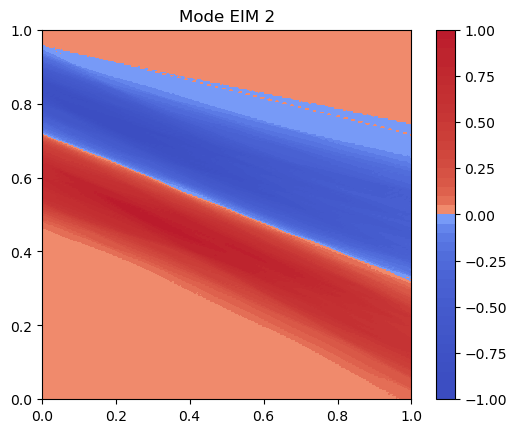

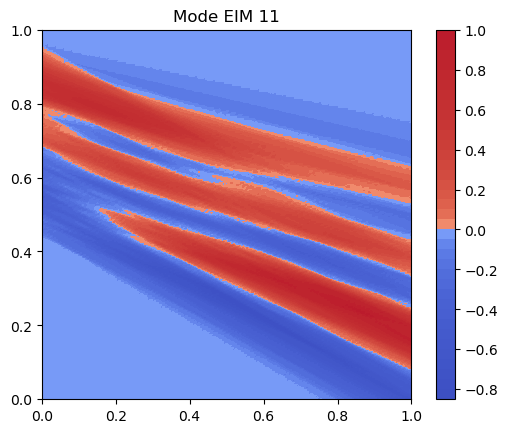

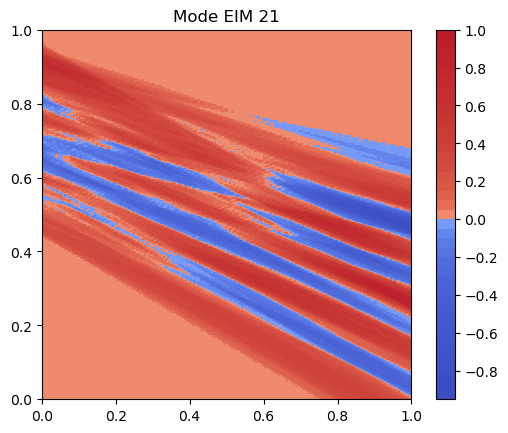

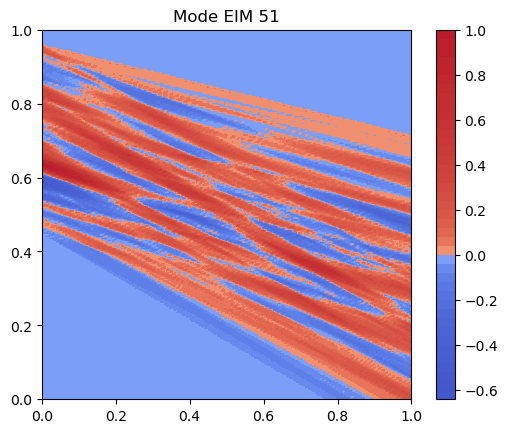

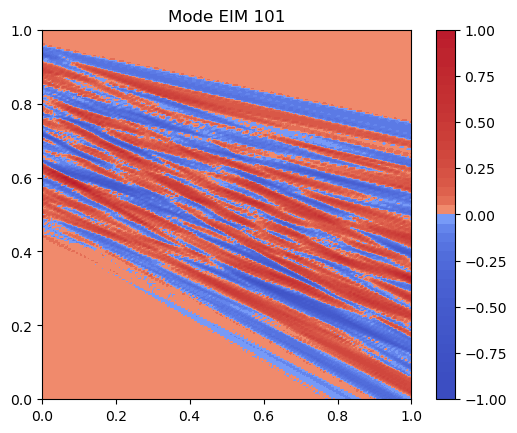

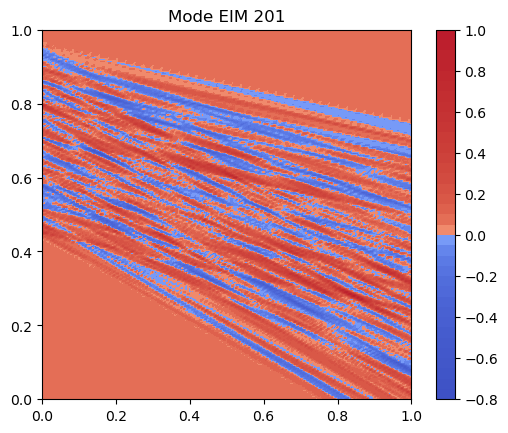

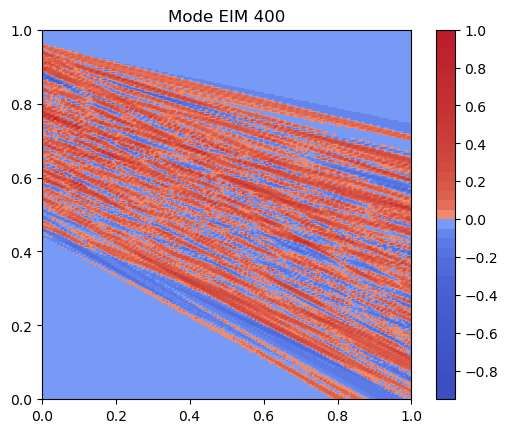

In [55]:
# Visualisation des modes EIM
for i in [1, 10, 20, 50, 100, 200, 399]:  # Quelques indices de modes à visualiser
    mode_fenics = numpy_to_fenics_param(Q[i, :], V)
    plt.figure()
    p = plot(mode_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=-1.0, vmax=1.5))
    plt.colorbar(p)
    plt.title(f"Mode EIM {i+1}")


Visualisation de l'approximation EIM: 100%|██████████| 8/8 [00:00<00:00, 12.88it/s]


Text(0.5, 1.0, 'Conductivité de référence g(mu) pour le premier cas de test')

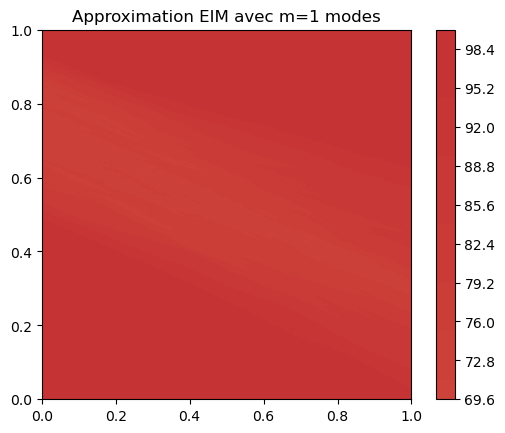

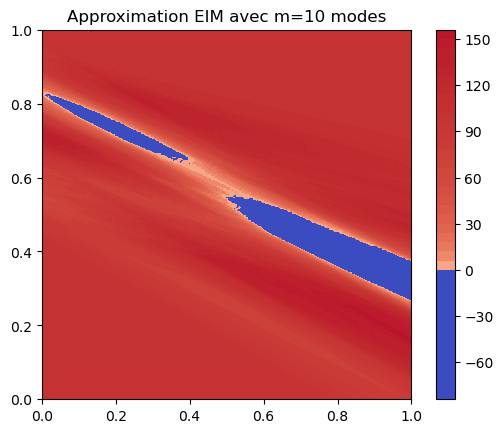

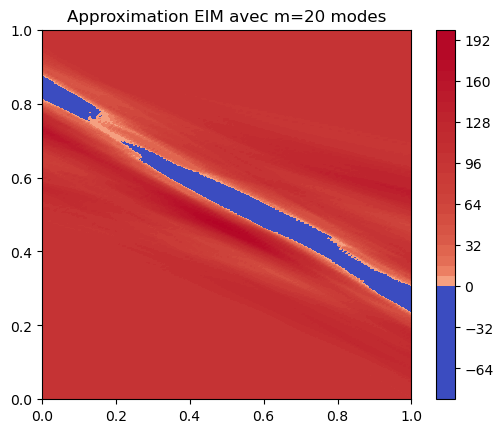

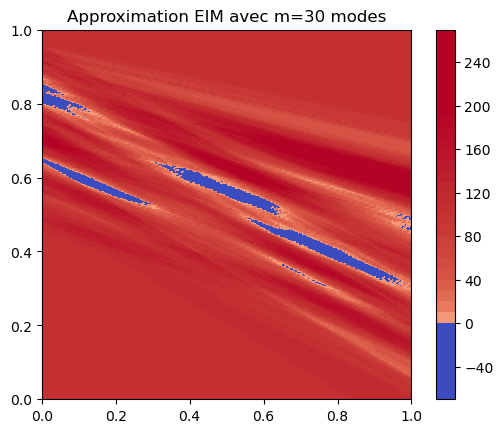

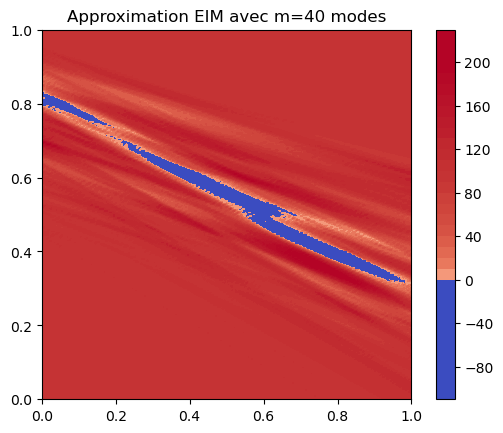

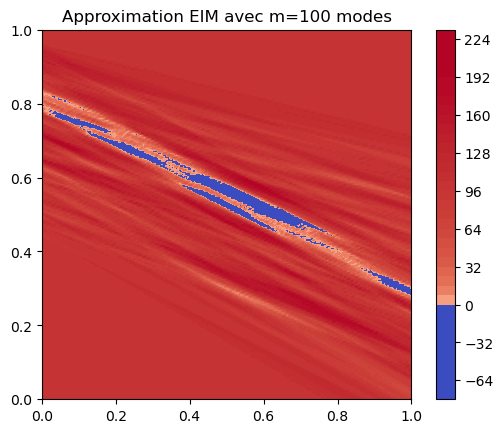

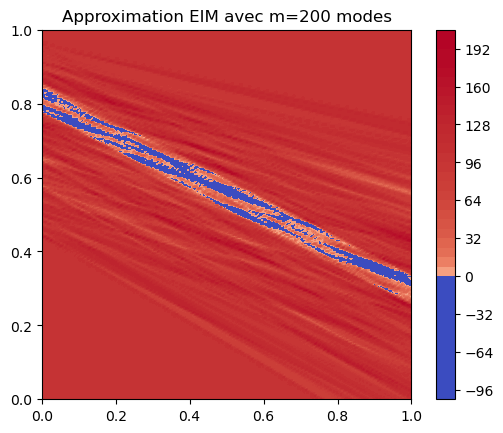

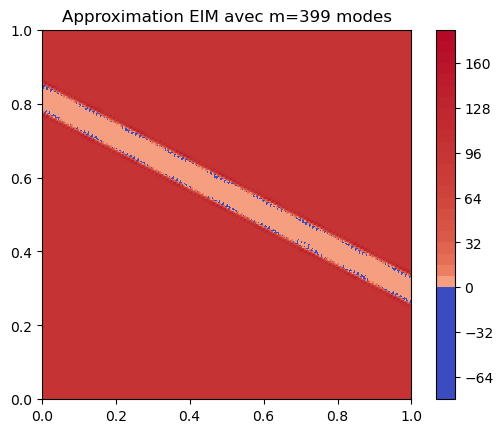

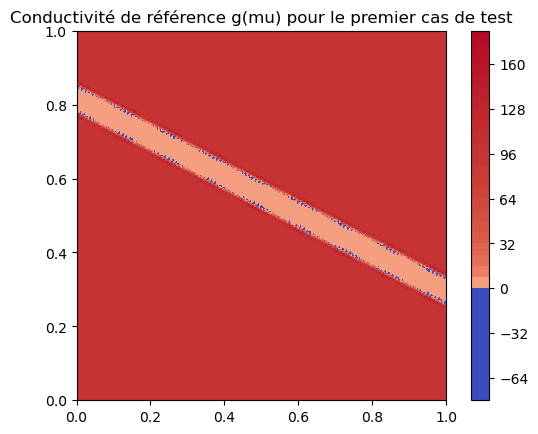

In [56]:
G_test = Snapshots_conductivite[0, :]  # On prend le premier snapshot de test comme conductivité de référence   
for m in tqdm([1, 10, 20, 30, 40, 100, 200, 399], desc="Visualisation de l'approximation EIM"):
    q_m = Q[m-1, :]
    
    G = np.array([G_test[Magic_Points[k]] for k in range(m)])
    beta = np.linalg.solve(B_complet[:m, :m], G)
    g_f = beta @ Q[:m, :]
    g_f_fenics = numpy_to_fenics_param(g_f, V)
    plt.figure()
    p = plot(g_f_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
    plt.colorbar(p)
    plt.title(f"Approximation EIM avec m={m} modes")

plt.figure()
p = plot(numpy_to_fenics_param(G_test, V),
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
plt.colorbar(p)
plt.title("Conductivité de référence g(mu) pour le premier cas de test")

## maintenant sur une une conductivité qui n'est pas dans la snapshot

Visualisation de l'approximation EIM pour un paramètre réel:   0%|          | 0/6 [00:00<?, ?it/s]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


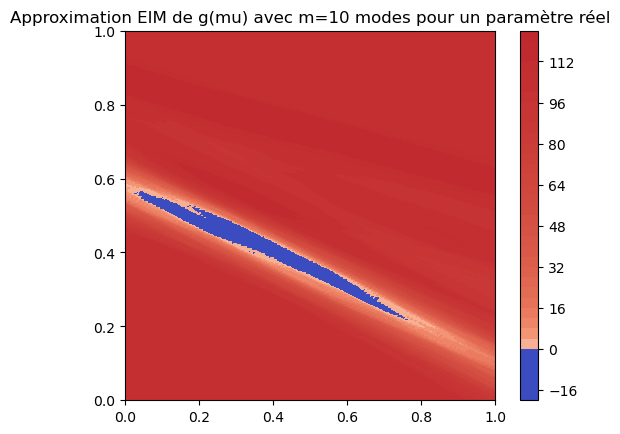

Visualisation de l'approximation EIM pour un paramètre réel:  17%|█▋        | 1/6 [00:02<00:14,  2.93s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


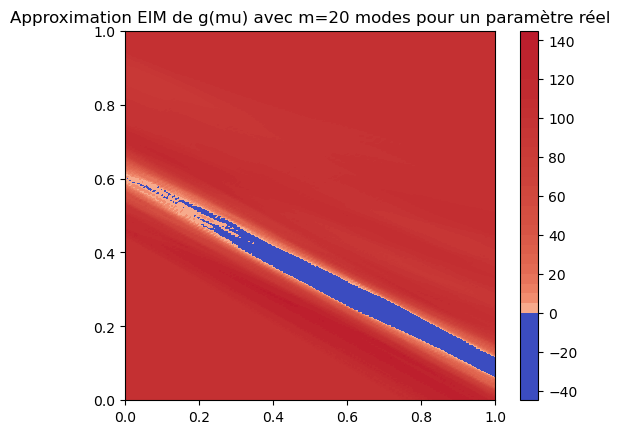

Visualisation de l'approximation EIM pour un paramètre réel:  33%|███▎      | 2/6 [00:05<00:11,  2.94s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


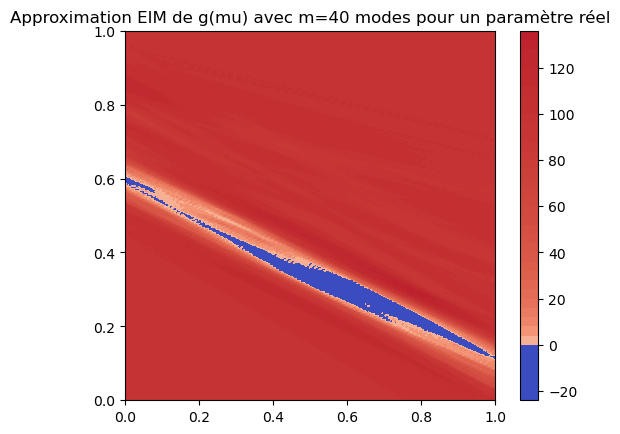

Visualisation de l'approximation EIM pour un paramètre réel:  50%|█████     | 3/6 [00:08<00:08,  2.90s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


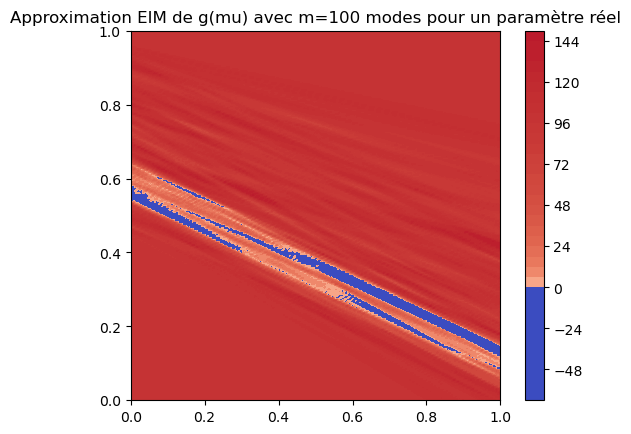

Visualisation de l'approximation EIM pour un paramètre réel:  67%|██████▋   | 4/6 [00:12<00:06,  3.20s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


KeyboardInterrupt: 

In [174]:
G_param = parameters_test_non_lineaire_list[0]
erreur_conductivite = np.zeros(len(Ns_non_lineaire_range))
K_param = get_conductivity(G_param)
K_fenics = project(K_param, V)
K_vect = K_fenics.vector().get_local()
for j, m in enumerate(tqdm([10, 20, 40, 100, 200, 300], desc="Visualisation de l'approximation EIM pour un paramètre réel")):
    G = np.array([K_vect[Magic_Points[k]] for k in range(m)])
    beta = np.linalg.solve(B_complet[:m, :m], G)
    g_f = beta @ Q[:m, :]
    g_f_fenics = numpy_to_fenics_param(g_f, V)
    erreur_conductivite[j] = errornorm(K_fenics, g_f_fenics, 'L2')
    p = plot(g_f_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
    plt.colorbar(p)
    plt.title(f"Approximation EIM de g(mu) avec m={m} modes pour un paramètre réel")
    plt.show()


plt.figure()
p = plot(K_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
plt.colorbar(p)
plt.title("Conductivité g(mu) pour le premier cas de test (FEniCS)")


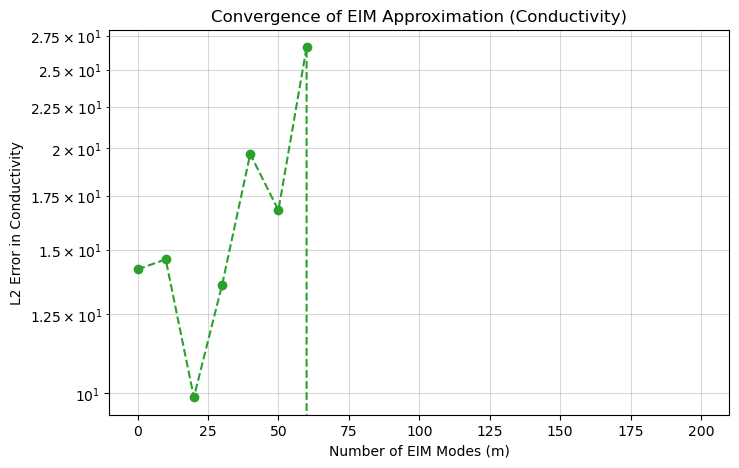

In [ ]:

plt.figure(figsize=(8, 5))
plt.semilogy(Ns_non_lineaire_range, erreur_conductivite, marker='o', color='tab:green', linestyle='--')
plt.xlabel('Number of EIM Modes (m)')
plt.ylabel('L2 Error in Conductivity')
plt.title('Convergence of EIM Approximation (Conductivity)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Finally, our coefficient function approximation is the interpolant of $g$ over $\mathcal{T}_M$ as defined from Lemma 2.3:

$$
g_M(x; \mu) = \sum_{m=1}^{M} \beta_m(\mu) q_m(x),
$$

where

$$
\sum_{j=1}^{M} B_{ij}^M \beta_j (\mu) = g(t_i; \mu), \quad 1 \leq i \leq M.
$$



In [ ]:
def get_A_b_EIM(q):
    K = numpy_to_fenics_param(q, V)
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx
    
    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

In [ ]:
Vt_EIM.shape


(400, 160801)

In [ ]:
U_nl.shape

(160801, 200)

In [ ]:
r_EIM = 20 # Par exemple (choisis le nombre de modes POD r que tu as fixé)
A_reduit_EIM_list = []
b_reduit_EIM_list = []
V_r = U_nl[:, :r_EIM]
print("Projection hors-ligne des modes EIM...")
for m in tqdm(range(300), desc="Calcul des A et b pour les modes EIM"):
    # On récupère le m-ième mode EIM
    q_m = Q[m, :]   

    
    # 1. On assemble les matrices Haute Fidélité pour ce mode EIM spécifique
    A_EIM, b_EIM = get_A_b_EIM(q_m)
    
    # 2. On les projette sur la base POD V_r (CORRECTION ICI)
    A_red_EIM = build_reduced_stiffness(A_EIM, V_r)
    b_red_EIM = build_reduced_load(b_EIM, V_r)
    
    # 3. On stocke dans la liste
    A_reduit_EIM_list.append(A_red_EIM)
    b_reduit_EIM_list.append(b_red_EIM)

print("Matrices réduites EIM générées avec succès !")


Projection hors-ligne des modes EIM...


Calcul des A et b pour les modes EIM: 100%|██████████| 300/300 [01:10<00:00,  4.29it/s]

Matrices réduites EIM générées avec succès !


In [ ]:
M_EIM = range(1, 300, 15) 
error_L2_EIM = np.zeros(len(M_EIM))
time_EIM = np.zeros(len(M_EIM))

A_test_list = []
b_test_list = []
HF_sol_list = []
g_test_list = []

print("Pré-calcul des solutions HF et des champs de conductivité...")
for i, params in enumerate(tqdm(parameters_test_non_lineaire_list, desc="Pré-calcul FEniCS")):
    # On calcule la matrice et le second membre
    A_test, b_test = get_stiffness_and_load(params)
    A_test_list.append(A_test)
    b_test_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list.append(u_full)
    
    # On paie le prix de FEniCS (project) UNE SEULE FOIS par paramètre
    G_array = g(params).vector().get_local()
    g_test_list.append(G_array)

Pré-calcul des solutions HF et des champs de conductivité...


Pré-calcul FEniCS: 100%|██████████| 10/10 [00:33<00:00,  3.36s/it]


In [ ]:
# On extrait les coordonnées géométriques de tous les degrés de liberté (1 seule fois)
dof_coords = V.tabulate_dof_coordinates()

def g_point(mu, point_idx):
    """
    Évalue la conductivité EXACTEMENT au noeud spatial point_idx.
    Temps d'exécution : ~0.0001s.
    """
    if isinstance(mu, dict):
        parameters = mu
    else:
        parameters = {
            "slope": mu[0], "position": mu[1], "half_width": mu[2], 
            "D_background": mu[3], "D_fracture": mu[4]
        }
    
    K = get_conductivity(parameters)
    coord = dof_coords[point_idx]
    
    try:
        # L'étoile (*) est magique : elle déballe le tableau [x, y] en arguments K(x, y)
        return K(*coord)
    except Exception:
        # Code de secours robuste qui attrape TOUTES les erreurs (ValueError, TypeError, etc.)
        val = np.zeros(1)
        K.eval(val, coord)
        return val[0]

In [ ]:
print("\nLancement du benchmark Online EIM...")


for j, m in enumerate(tqdm(M_EIM, desc="Testing ROM with EIM")):
    
    for i, params in enumerate(parameters_test_non_lineaire_list):

        # Récupération de la conductivité de test pré-calculée
        g_mu_complet = g_test_list[i]

        # ----------------------------------------------------
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ----------------------------------------------------
        t0 = time()
        
        # On extrait comme de vrais "capteurs" physiques sur les Magic Points
        G = np.array([g_mu_complet[Magic_Points[k]] for k in range(m)])
        
        # Calcul des coefficients EIM (B[m-1] car l'index commence à 0)
        beta = np.linalg.solve(B_complet[:m, :m], G) # orriginal 

        #beta = np.linalg.lstsq(B_complet[:m, :m], G, rcond=None)[0] # Solution plus stable numériquement
        
        # Assemblage réduit EIM (Combinaison linéaire pure NumPy)
        A_red_EIM = np.sum([beta[k] * A_reduit_EIM_list[k] for k in range(m)], axis=0)
        b_red_EIM = np.sum([beta[k] * b_reduit_EIM_list[k] for k in range(m)], axis=0)
        
        # Résolution du petit système réduit
        u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        
        # Reconstruction rapide NumPy
        u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect
        
        t1 = time()
        # ----------------------------------------------------
        # FIN DU CHRONO
        # ----------------------------------------------------
        
        # POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 
        
        u_full = HF_sol_list[i]
        A_test = A_test_list[i]
        
        error_L2_EIM[j] += error_L2(u_full, u_approx_fenics)
        time_EIM[j] += (t1 - t0)

    # Moyennes
    error_L2_EIM[j] /= len(parameters_test_non_lineaire_list) 
    time_EIM[j] /= len(parameters_test_non_lineaire_list)
    



Lancement du benchmark Online EIM...


Testing ROM with EIM: 100%|██████████| 20/20 [00:07<00:00,  2.65it/s]


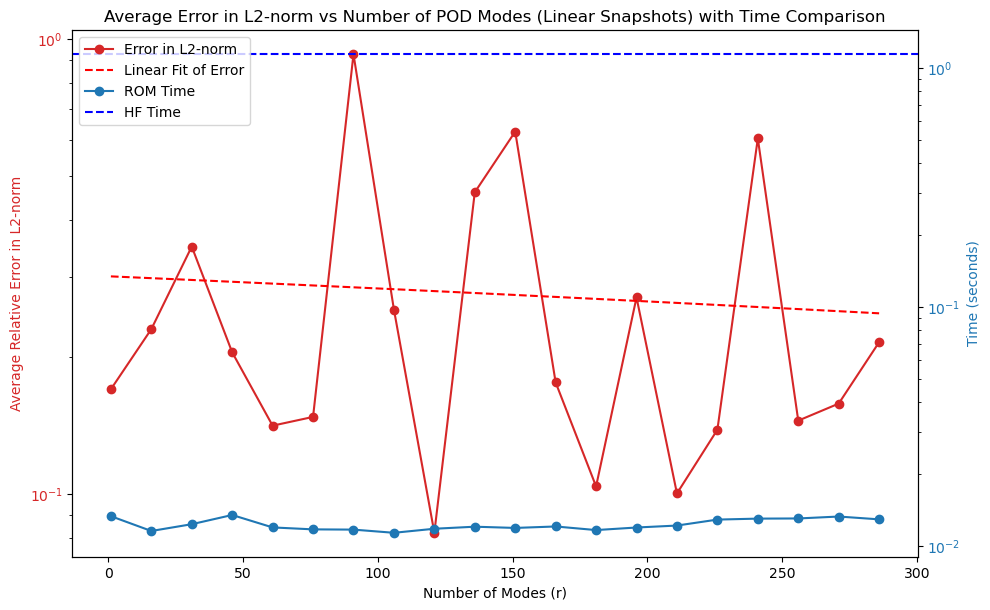

In [ ]:
from scipy import stats
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in L2-norm', color=color)
ax1.semilogy(M_EIM, error_L2_EIM, marker='o', color=color, label='Error in L2-norm')
ax1.tick_params(axis='y', labelcolor=color)

# Calculer la régression linéaire en échelle logarithmique
slope, intercept, r_value, p_value, std_err = stats.linregress(M_EIM, error_L2_EIM)
linear_fit = slope * M_EIM + intercept

# Plotter l'approximation linéaire de l'erreur en pointillé rouge
ax1.semilogy(M_EIM, linear_fit, 'r--', label='Linear Fit of Error')

# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()

# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(M_EIM, time_EIM, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)

# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Ajouter un titre
plt.title('Average Error in L2-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')

# Afficher le graphique
plt.show()

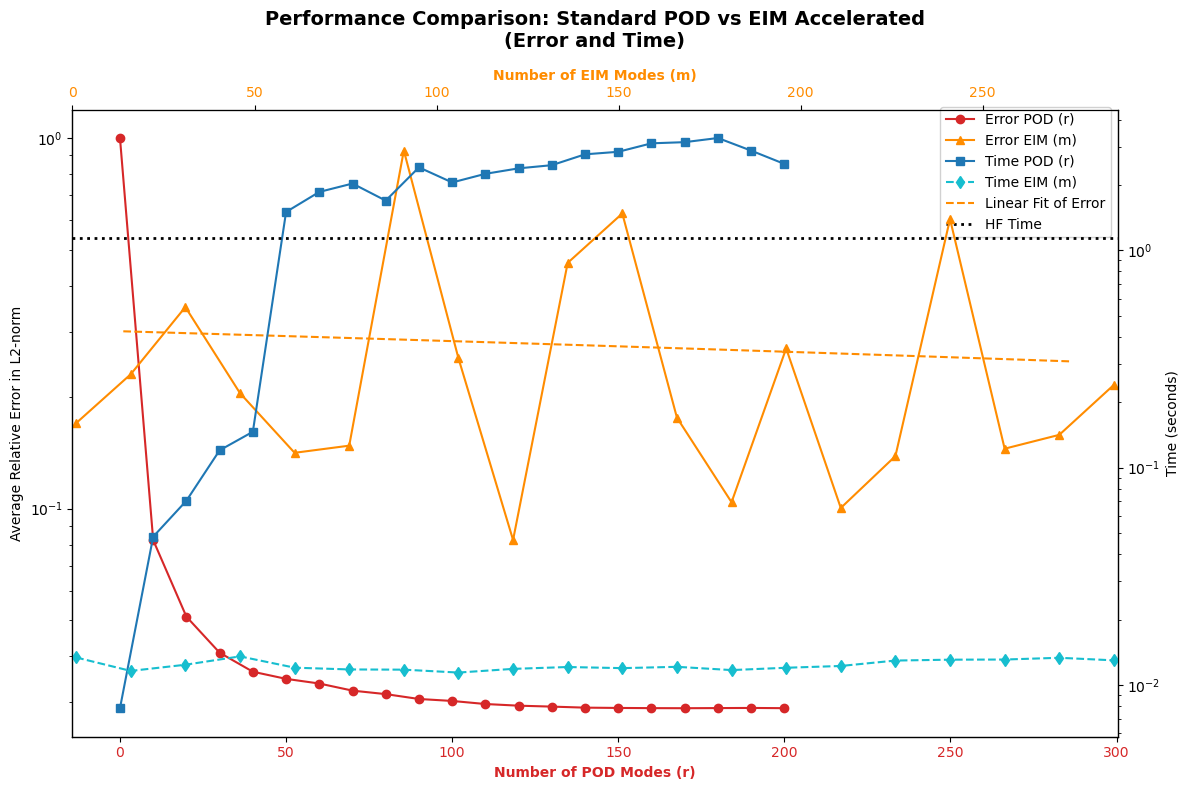

In [ ]:

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# 1. Erreur POD pure (Bas / Gauche)
color_err_pod = 'tab:red'
ax1.set_xlabel('Number of POD Modes (r)', color=color_err_pod, fontweight='bold')
ax1.set_ylabel('Average Relative Error in L2-norm', color='black')
l1, = ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='o', 
                   color=color_err_pod, label='Error POD (r)')
ax1.tick_params(axis='x', labelcolor=color_err_pod)

# 2. Erreur EIM (Haut / Gauche) -> Partage l'axe Y gauche (ax1.twiny)
ax3 = ax1.twiny()
color_err_eim = 'darkorange'
ax3.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax3.semilogy(M_EIM, error_L2_EIM, marker='^', 
                   color=color_err_eim, label='Error EIM (m)')
ax3.tick_params(axis='x', labelcolor=color_err_eim)
# Calculer la régression linéaire en échelle logarithmique
slope, intercept, r_value, p_value, std_err = stats.linregress(M_EIM, error_L2_EIM)
linear_fit = slope * M_EIM + intercept

# Plotter l'approximation linéaire de l'erreur en pointillé rouge
l5, = ax1.semilogy(M_EIM, linear_fit, color=color_err_eim, linestyle='--', label='Linear Fit of Error')


# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

# 3. Temps POD pure (Bas / Droite) -> Partage l'axe X bas (ax1.twinx)
ax2 = ax1.twinx()
color_time_pod = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color='black')
# J'ai mis semilogy ici pour que les temps soient comparables, tu peux remettre .plot si besoin
l2, = ax2.semilogy(Ns_non_lineaire_range, time_non_linear, marker='s', 
                   color=color_time_pod, label='Time POD (r)')

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# 4. Temps EIM (Haut / Droite) -> Partage l'axe Y droit et crée un nouvel axe X (ax2.twiny)
ax4 = ax2.twiny()
color_time_eim = 'tab:cyan'
l4, = ax4.semilogy(M_EIM, time_EIM, marker='d', linestyle='--', 
                   color=color_time_eim, label='Time EIM (m)')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================

# Cacher la graduation X de ax4 car ax3 affiche déjà l'échelle "m" en haut
ax4.set_xticks([])
ax4.spines['top'].set_visible(False)

# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax3.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax4.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l1, l3, l2, l4, l5, l_hf]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='center right', bbox_to_anchor=(1, 0.9), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance Comparison: Standard POD vs EIM Accelerated\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

évolution de la solution approchée en fonction du nombre de modes EIM :


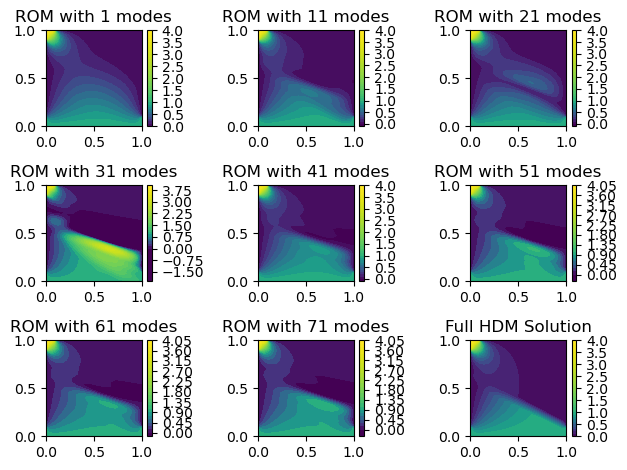

In [178]:
print("évolution de la solution approchée en fonction du nombre de modes EIM :")
for m in range(1, 81, 10):
    G = np.array([g_mu_complet[Magic_Points[k]] for k in range(m)])
        
    # Calcul des coefficients EIM (B[m-1] car l'index commence à 0)
    beta = np.linalg.solve(B_complet[:m, :m], G) # orriginal 

    #beta = np.linalg.lstsq(B_complet[:m, :m], G, rcond=None)[0] # Solution plus stable numériquement
        
    # Assemblage réduit EIM (Combinaison linéaire pure NumPy)
    A_red_EIM = np.sum([beta[k] * A_reduit_EIM_list[k] for k in range(m)], axis=0)
    b_red_EIM = np.sum([beta[k] * b_reduit_EIM_list[k] for k in range(m)], axis=0)
        
        # Résolution du petit système réduit
    u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        
        # Reconstruction rapide NumPy
    u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect

    u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 

    plt.subplot(3, 3, m//10 + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {m} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(3, 3, 9)
u_full = HF_sol_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Maintenant avec une fonction de conductivité $C^{\infty}$

In [5]:
def sigmoide(expr):
    return 1.0 / (1.0 + exp(-400*expr))

def get_conductivity_Cinf(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (sigmoide(arg1) + sigmoide(arg2)) + D_fracture * sigmoide(arg3) * sigmoide(arg4)

    return K

In [6]:

def get_stiffness_and_load_Cinf(parameters):
    K = get_conductivity_Cinf(parameters)
    
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod


In [7]:
def plot_conductivity_Cinf(parameters):
    K = get_conductivity_Cinf(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="coolwarm", vmin=0.-20, vmax=140.0)
    plt.colorbar(p)
    plt.title("Conductivity Cinf K(x,y)")

plot_conductivity_Cinf(example_parameters)


NameError: name 'example_parameters' is not defined

# En comparaison à avant :

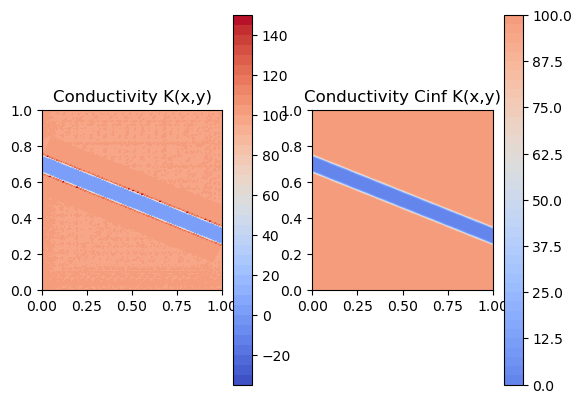

In [19]:
plt.subplot(1, 2, 1)
plot_conductivity(example_parameters)
plt.subplot(1, 2, 2)
plot_conductivity_Cinf(example_parameters)

In [20]:
A_mu_Cinf, b_mu_Cinf = get_stiffness_and_load_Cinf(example_parameters)
uh_HDM_sol_Cinf = Function(V)
solve(A_mu_Cinf, uh_HDM_sol_Cinf.vector(), b_mu_Cinf)
uh_HDM_sol_Cinf_vec = np.array(uh_HDM_sol_Cinf.vector().get_local()) + u_L_vect

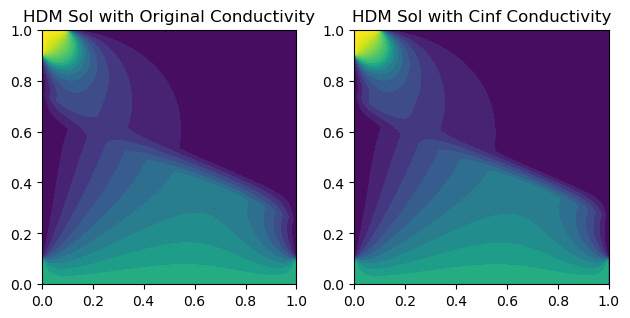

In [21]:
plt.subplot(1, 2, 1)
plot(uh_HDM_sol, cmap="viridis", norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("HDM Sol with Original Conductivity")
plt.subplot(1, 2, 2)
plot(uh_HDM_sol_Cinf, cmap="viridis", norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("HDM Sol with Cinf Conductivity")
plt.tight_layout()
plt.show()


In [25]:
U_snapshot_non_lineaire_Cinf = np.zeros((N_dof, Ns_non_lineaire))
print("dimension de U_snapshot:", U_snapshot_non_lineaire_Cinf.shape)

dimension de U_snapshot: (160801, 200)


In [26]:
for i in tqdm(range(Ns_non_lineaire), desc="Génération des Snapshots"):
    A_mu, b_mu = get_stiffness_and_load(parameters_list_non_lineaire[i])
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_non_lineaire_Cinf[:, i] = uh_HDM_sol_vec


Génération des Snapshots:   0%|          | 0/200 [00:00<?, ?it/s]


NameError: name 'parameters_list_non_lineaire' is not defined

In [243]:
U_nl_Cinf, S_nl_Cinf, Vt_nl_Cinf = np.linalg.svd(U_snapshot_non_lineaire_Cinf, full_matrices=False)

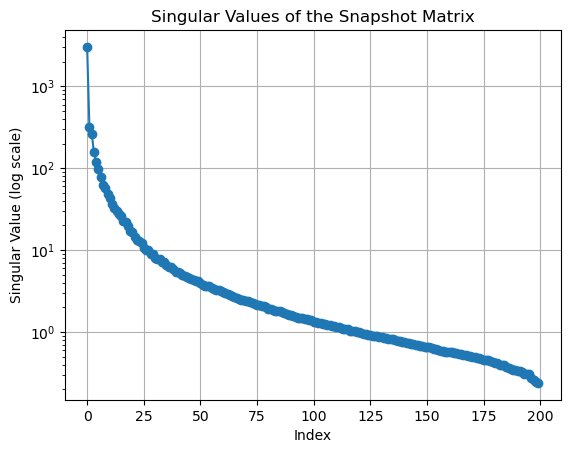

In [244]:
plt.semilogy(S_nl_Cinf, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

Energy percentage: [ 97.38652872  98.47245067  99.20710096  99.47117959  99.61794378
  99.71875688  99.78460205  99.82615917  99.86017781  99.88547322
  99.90574296  99.91963586  99.930795    99.94030266  99.94848284
  99.95579702  99.96116732  99.96630262  99.97035936  99.97349063
  99.97642322  99.97863135  99.98049653  99.98229698  99.98384916
  99.98505196  99.98612465  99.98716173  99.98802983  99.9888824
  99.98955621  99.99021218  99.9908511   99.99140258  99.99192938
  99.99239818  99.99281635  99.99321552  99.9935824   99.99389679
  99.99419876  99.9944865   99.9947397   99.99498176  99.99521295
  99.99542872  99.99563634  99.99583571  99.99602079  99.99620147
  99.99636845  99.99652009  99.99666285  99.99680524  99.99694294
  99.99706547  99.99718064  99.99729266  99.99740243  99.99750542
  99.99760467  99.9976988   99.99779009  99.9978762   99.99795758
  99.99803223  99.99810358  99.99817202  99.99823667  99.99829965
  99.99835963  99.9984185   99.99847467  99.99852747  99.9

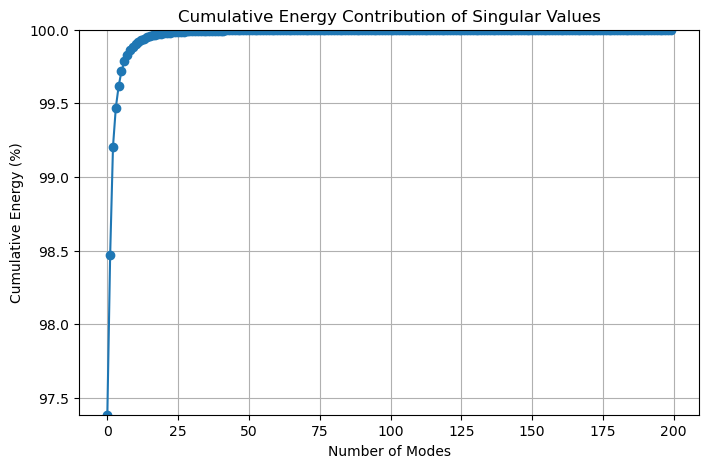

In [245]:
plot_energy_contribution(S_nl_Cinf)

In [375]:
error_A_non_lineaire_Cinf = np.zeros(len(Ns_non_lineaire_range))
error_L2_non_lineaire_Cinf = np.zeros(len(Ns_non_lineaire_range))
time_non_linear_Cinf = np.zeros(len(Ns_non_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_non_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load_Cinf(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_non_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_nl[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_list_Cinf = []
b_test_list_Cinf = []
HF_sol_list_Cinf = []
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load_Cinf(params)
    A_test_list_Cinf.append(A_test)
    b_test_list_Cinf.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list_Cinf.append(u_full)




for j, r in enumerate(tqdm(Ns_non_lineaire_range, desc="Testing ROM with non-linear snapshots")):
    for i, params in enumerate(parameters_test_non_lineaire_list):
        A_test = A_test_list_Cinf[i]
        b_test = b_test_list_Cinf[i]
        u_full = HF_sol_list_Cinf[i]
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 
        V_r = U_nl[:, :r]
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_non_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        error_L2_non_lineaire[j] += error_L2(u_full, u_approx_fenics)
        time_non_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_non_lineaire[j] /= len(parameters_test_non_lineaire_list) 
    error_L2_non_lineaire[j] /= len(parameters_test_non_lineaire_list)
    time_non_linear[j] /= len(parameters_test_non_lineaire_list)
    


Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Tour de chauffe terminé ! Lancement du benchmark...


Testing ROM with non-linear snapshots: 100%|██████████| 21/21 [05:53<00:00, 16.81s/it]


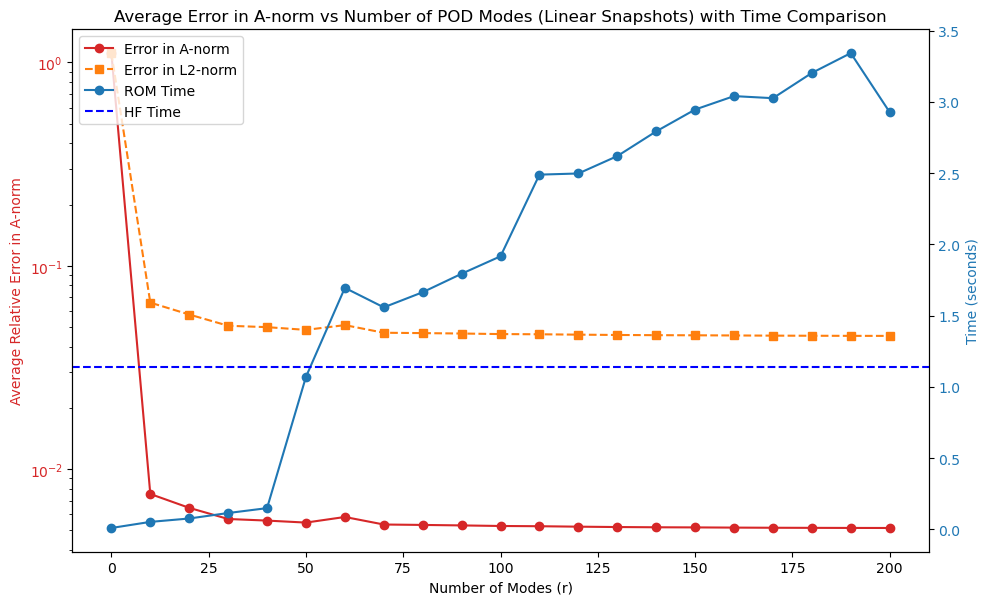

In [376]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_non_lineaire_range, error_A_non_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Plotter l'erreur en norme L2 sur l'axe principal (gauche)
color = 'tab:orange'
ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='s', color=color, linestyle='--', label='Error in L2-norm')
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

## L'EIM en $C^\infty$

In [263]:
def g_Cinf(mu):
    """
    Accepte mu sous forme de dictionnaire ou de liste/array.
    """
    if isinstance(mu, dict):
        # Si c'est déjà un dictionnaire, on l'utilise tel quel
        parameters = mu
    else:
        # Si c'est une liste, on la convertit
        parameters = {
            "slope": mu[0], 
            "position": mu[1], 
            "half_width": mu[2], 
            "D_background": mu[3], 
            "D_fracture": mu[4]
        }
        
    K = get_conductivity_Cinf(parameters)
    return project(K, V)


M_max = 400

MU_MIN = [
    20.0,
    50.0,
    3.0
]

# --- BORNES SUPÉRIEURES (MAX) ---
MU_MAX = [
    60.0,
    90.0,
    7.0
]

In [254]:
def compute_single_snapshot_Cinf(mu):
    # On appelle ta fonction g_Cinf(mu)
    G = g_Cinf(mu)
    return G.vector().get_local()

# --- CONFIGURATION ---
N_train = len(D_train)
print(f"Création de la Matrice : {N_train} paramètres.")

# ====================================================================
# L'AJOUT MAGIQUE : LE TIR D'ÉCHAUFFEMENT (PRÉ-COMPILATION)
# ====================================================================
print("Échauffement de FEniCS (Compilation JIT séquentielle)...")
# FEniCS va compiler tranquillement sur un seul coeur
_ = compute_single_snapshot_Cinf(D_train[0])
print("Compilation terminée ! Le cache est prêt pour la parallélisation.")

# ====================================================================
# LA BOUCLE PARALLÈLE
# ====================================================================
# Lancement avec le backend 'threading'
results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(compute_single_snapshot_Cinf)(mu) for mu in tqdm(D_train, desc="Phase Offline Parallèle")
)

Snapshots_conductivite_Cinf = np.array(results)
print(f"\nTerminé ! Forme de la matrice : {Snapshots_conductivite_Cinf.shape}")

# Sauvegarde de sécurité vitale (pour ne pas pleurer si le notebook freeze plus tard)
np.save("snapshots_Cinf_backup.npy", Snapshots_conductivite_Cinf)

Création de la Matrice : 400 paramètres.
Échauffement de FEniCS (Compilation JIT séquentielle)...
Compilation terminée ! Le cache est prêt pour la parallélisation.





Phase Offline Parallèle:   6%|▌         | 22/400 [00:11<01:54,  3.29it/s]IOStream.flush timed out



Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.


python(40507) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40508) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40509) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40510) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40511) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40515) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40516) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40518) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40519) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40520) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(40521) Malloc

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


python(42279) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.


python(42284) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42285) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Terminé ! Forme de la matrice : (400, 160801)


In [256]:
U_EIM_Cinf, S_EIM_Cinf, Vt_EIM_Cinf = np.linalg.svd(Snapshots_conductivite_Cinf, full_matrices=False)

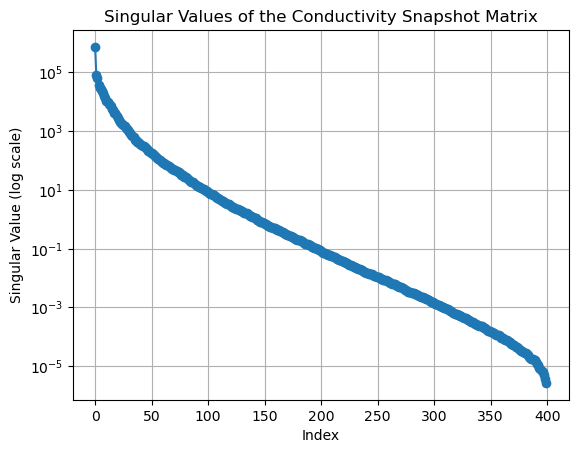

In [257]:
plt.semilogy(S_EIM_Cinf, marker='o', label='Singular Values (Conductivity Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Conductivity Snapshot Matrix')
plt.grid()
plt.show()

Energy percentage: [ 97.09326922  98.34694767  99.09232732  99.35963189  99.52467123
  99.6486236   99.75270544  99.82047926  99.8677427   99.90264681
  99.92391146  99.94123057  99.95474475  99.96531244  99.97429276
  99.98004541  99.98502299  99.98815684  99.99109399  99.99302921
  99.99443289  99.99546005  99.99618348  99.99687042  99.9974607
  99.99792869  99.99835647  99.99864075  99.99887501  99.99908104
  99.99923236  99.99936313  99.9994678   99.99955246  99.99962901
  99.99967737  99.99971986  99.99975455  99.99978632  99.99981461
  99.99983731  99.99985811  99.99987682  99.99989389  99.99990835
  99.99992178  99.99993267  99.99994076  99.99994873  99.99995493
  99.99996102  99.99996643  99.9999706   99.99997433  99.99997735
  99.99998024  99.99998267  99.99998467  99.99998641  99.99998786
  99.9999891   99.99999025  99.99999129  99.99999225  99.99999313
  99.99999391  99.99999457  99.99999516  99.99999564  99.99999611
  99.99999656  99.99999694  99.99999728  99.99999761  99.9

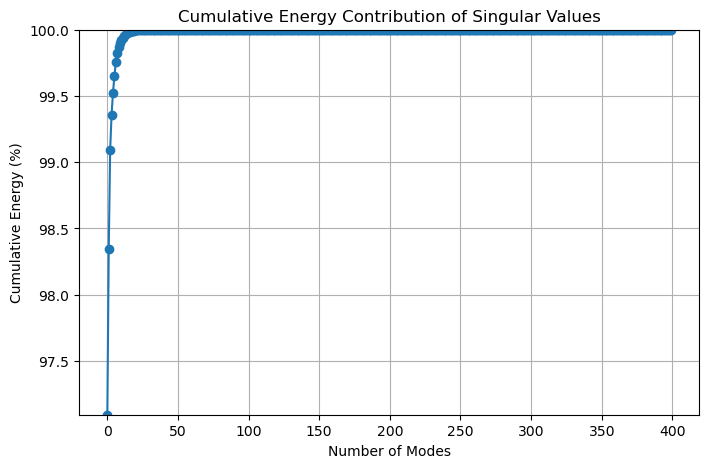

In [291]:
plot_energy_contribution(S_EIM_Cinf)

In [264]:

nb_dofs_Cinf = V.dim()

Q_Cinf = np.zeros((M_max, nb_dofs_Cinf))  # Base de fonctions q_m (normalisées)
Magic_Points_Cinf = []                   # Ensemble des t_m (les indices)
S_mu_Cinf = []                           # Paramètres sélectionnés

# Ps on remarque que les coeffs de l'articles B_ij^M sont indépendant de M donc on peut faire que une matrice 
B_complet_Cinf = np.zeros((M_max, M_max))
print("Lancement de l'algorithme DEIM (SVD + Magic Points)...")

for m in tqdm(range(M_max), desc="Construction de la base DEIM"):
    
    # =======================================================
    # 1. SÉLECTION DU MODE (Fini le Greedy, merci la SVD !)
    # =======================================================
    # Le m-ième mode spatial dominant est simplement la m-ième ligne de Vt_EIM
    xi_M = Vt_EIM_Cinf[m, :]

    # =======================================================
    # 2. CONSTRUCTION DU NOUVEAU MODE EIM/DEIM
    # =======================================================
    if m == 0:
        # Premier mode
        t_1 = np.argmax(np.abs(xi_M))
        q_1 = xi_M / xi_M[t_1]
        
        Magic_Points_Cinf.append(t_1)
        Q_Cinf[0, :] = q_1
        B_complet_Cinf[0, 0] = 1.0
        
    else:
        # Modes suivants
        T_current = Magic_Points_Cinf[:m]
        
        # Résolution pour trouver le résidu
        xi_magic = xi_M[T_current]
        sigma = np.linalg.solve(B_complet_Cinf[:m, :m], xi_magic)
        
        # Le fameux résidu r_M
        r_M = xi_M - (sigma @ Q_Cinf[:m, :])
        
        # Le nouveau Magic Point t_M
        t_M = np.argmax(np.abs(r_M))
        Magic_Points_Cinf.append(t_M)
        
        # La nouvelle base q_M normalisée
        q_M = r_M / r_M[t_M]
        Q_Cinf[m, :] = q_M
        
        # Mise à jour de la matrice B
        for i in range(m + 1):
            for j in range(m + 1):
                B_complet_Cinf[i, j] = Q_Cinf[j, Magic_Points_Cinf[i]]


print("\nBase DEIM générée avec succès !")

Lancement de l'algorithme DEIM (SVD + Magic Points)...


Construction de la base DEIM: 100%|██████████| 400/400 [00:10<00:00, 39.08it/s] 


Base DEIM générée avec succès !


In [387]:
r_EIM = 100 # Taille de la base spatiale POD
V_r = U_nl_Cinf[:, :r_EIM]

# =======================================================
# L'ASTUCE MAGIQUE : Isoler le terme source constant
# =======================================================
print("Extraction du terme source constant (K = 0)...")
_, b_zero_HF = get_A_b_EIM(np.zeros(V.dim()))
b_source_red = build_reduced_load(b_zero_HF, V_r)


A_reduit_EIM_Cinf_list = []
b_reduit_EIM_Cinf_list = []

print("Projection hors-ligne des modes EIM...")
for m in tqdm(range(50), desc="Calcul des A et b pour les modes EIM"):
    # On récupère le m-ième mode EIM
    q_m = Q_Cinf[m, :]   
    
    # 1. On assemble les matrices Haute Fidélité pour ce mode EIM spécifique
    A_EIM, b_EIM = get_A_b_EIM(q_m)
    
    # 2. On les projette sur la base POD V_r
    A_red_EIM = build_reduced_stiffness(A_EIM, V_r)
    b_red_EIM = build_reduced_load(b_EIM, V_r)
    
    # 3. On stocke dans la liste
    A_reduit_EIM_Cinf_list.append(A_red_EIM)
    b_reduit_EIM_Cinf_list.append(b_red_EIM)

print("Matrices réduites EIM générées avec succès !")

Extraction du terme source constant (K = 0)...
Projection hors-ligne des modes EIM...


Calcul des A et b pour les modes EIM: 100%|██████████| 50/50 [01:59<00:00,  2.39s/it]

Matrices réduites EIM générées avec succès !


In [341]:
# On assemble le système avec K = 0 pour isoler la partie constante de b
_, b_zero_HF = get_A_b_EIM(np.zeros(V.dim()))
b_source_red = build_reduced_load(b_zero_HF, V_r)

In [347]:
M_EIM = range(1, 51, 5) 
error_L2_EIM_Cinf = np.zeros(len(M_EIM))
time_EIM_Cinf = np.zeros(len(M_EIM))

A_test_list_Cinf = []
b_test_list_Cinf = []
HF_sol_list_Cinf = []
g_test_list_Cinf = []

print("Pré-calcul des solutions HF et des champs de conductivité...")
for i, params in enumerate(tqdm(parameters_test_non_lineaire_list, desc="Pré-calcul FEniCS")):
    # On calcule la matrice et le second membre
    A_test, b_test = get_stiffness_and_load_Cinf(params)
    A_test_list_Cinf.append(A_test)
    b_test_list_Cinf.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list_Cinf.append(u_full)
    
    # On paie le prix de FEniCS (project) UNE SEULE FOIS par paramètre
    G_array = g_Cinf(params).vector().get_local()
    g_test_list_Cinf.append(G_array)

Pré-calcul des solutions HF et des champs de conductivité...


Pré-calcul FEniCS: 100%|██████████| 10/10 [00:34<00:00,  3.47s/it]


In [348]:
# On extrait les coordonnées géométriques de tous les degrés de liberté (1 seule fois)
dof_coords = V.tabulate_dof_coordinates()

def g_point_Cinf(mu, point_idx):
    """
    Évalue la conductivité EXACTEMENT au noeud spatial point_idx.
    Temps d'exécution : ~0.0001s.
    """
    if isinstance(mu, dict):
        parameters = mu
    else:
        parameters = {
            "slope": mu[0], "position": mu[1], "half_width": mu[2], 
            "D_background": mu[3], "D_fracture": mu[4]
        }
    
    K = get_conductivity_Cinf(parameters)
    coord = dof_coords[point_idx]
    
    try:
        # L'étoile (*) est magique : elle déballe le tableau [x, y] en arguments K(x, y)
        return K(*coord)
    except Exception:
        # Code de secours robuste qui attrape TOUTES les erreurs (ValueError, TypeError, etc.)
        val = np.zeros(1)
        K.eval(val, coord)
        return val[0]

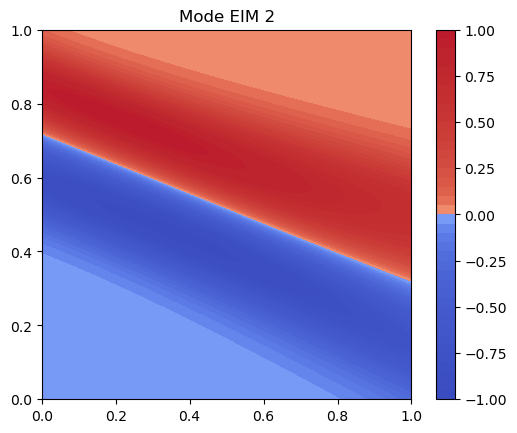

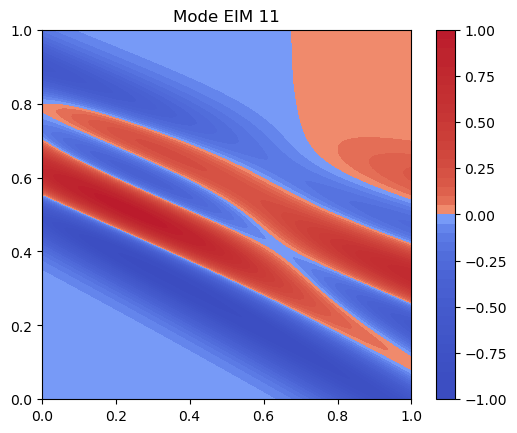

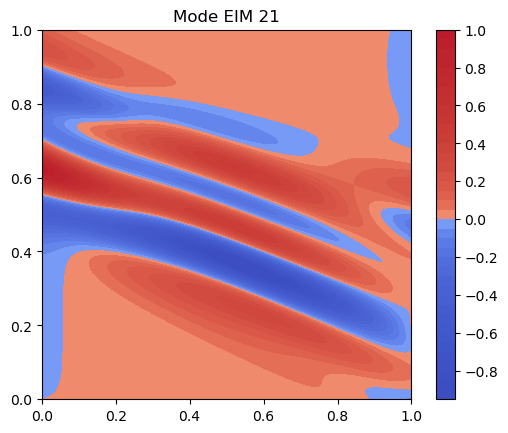

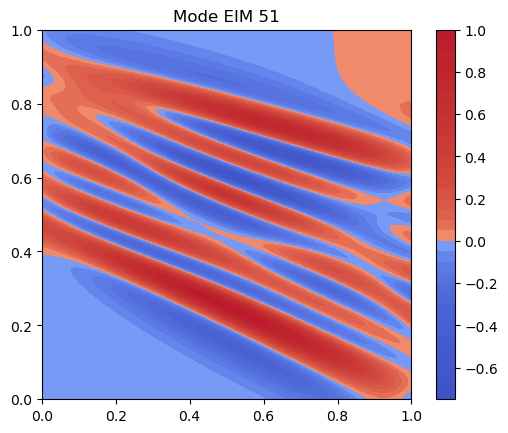

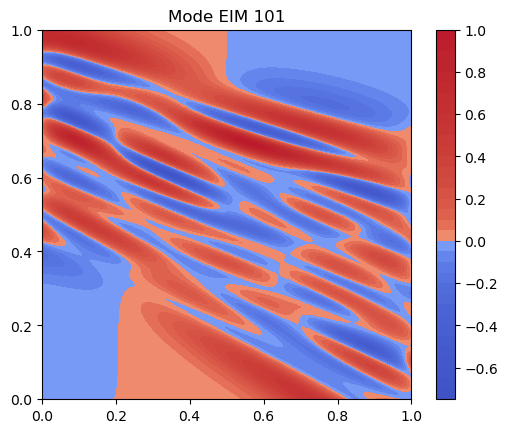

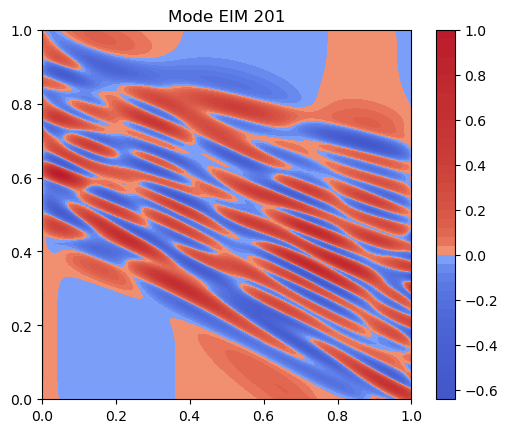

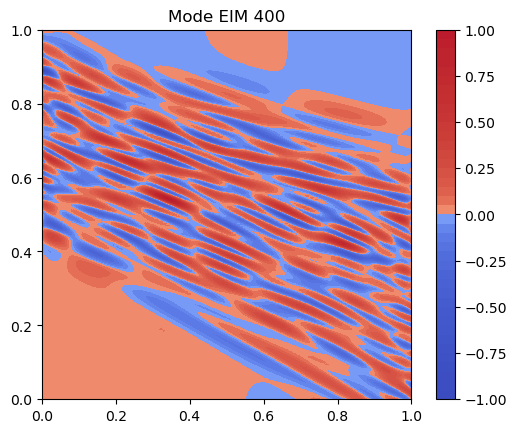

In [349]:
# Visualisation des modes EIM
for i in [1, 10, 20, 50, 100, 200, 399]:  # Quelques indices de modes à visualiser
    mode_fenics = numpy_to_fenics_param(Q_Cinf[i, :], V)
    plt.figure()
    p = plot(mode_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=-1.0, vmax=1.5))
    plt.colorbar(p)
    plt.title(f"Mode EIM {i+1}")


Visualisation de l'approximation EIM pour un paramètre réel:   0%|          | 0/6 [00:00<?, ?it/s]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


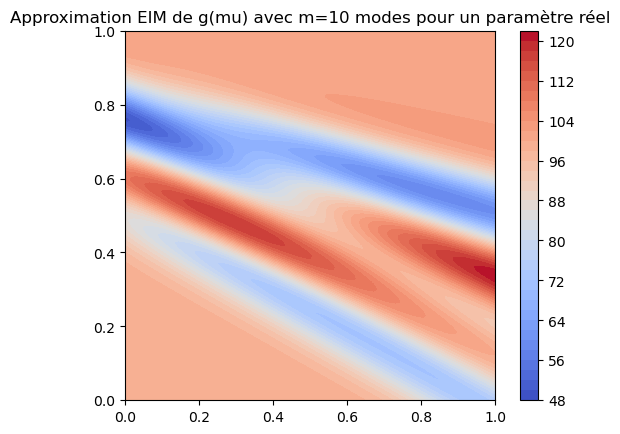

Visualisation de l'approximation EIM pour un paramètre réel:  17%|█▋        | 1/6 [00:02<00:14,  2.92s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


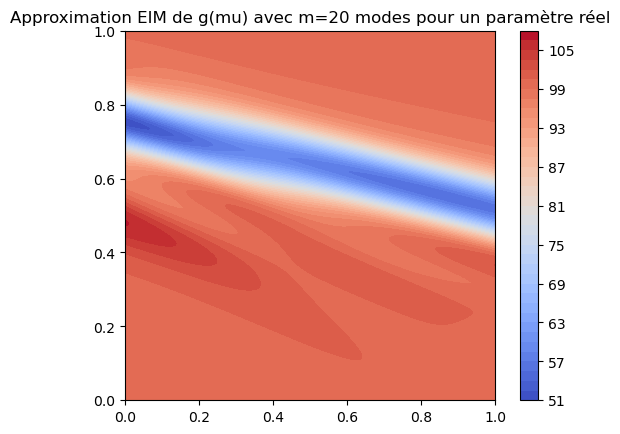

Visualisation de l'approximation EIM pour un paramètre réel:  33%|███▎      | 2/6 [00:05<00:10,  2.70s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


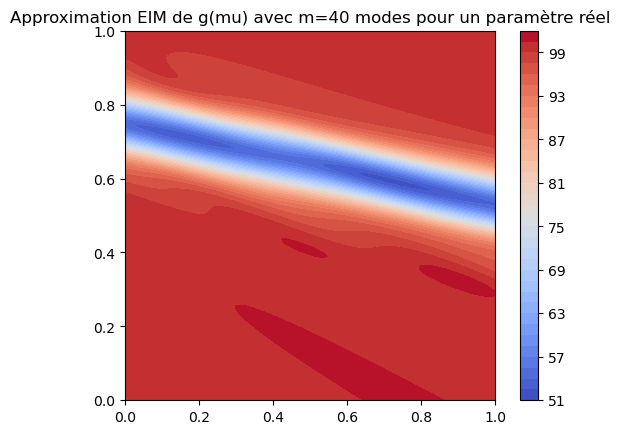

Visualisation de l'approximation EIM pour un paramètre réel:  50%|█████     | 3/6 [00:08<00:07,  2.67s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


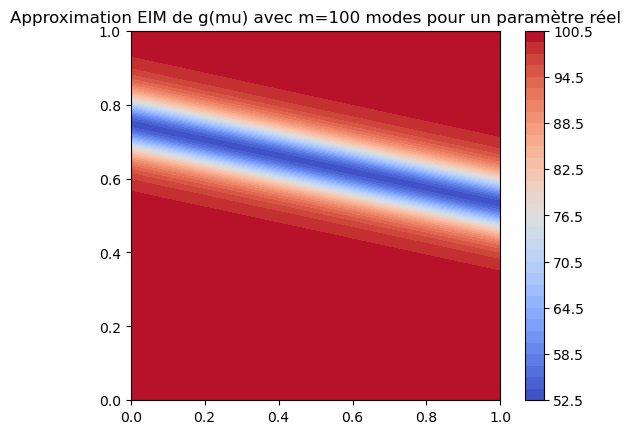

Visualisation de l'approximation EIM pour un paramètre réel:  67%|██████▋   | 4/6 [00:10<00:05,  2.63s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


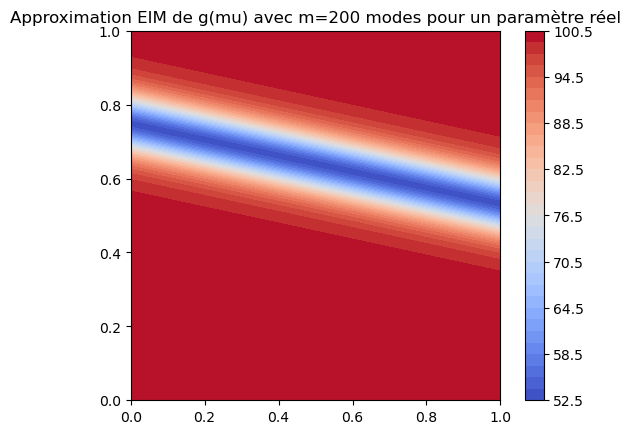

Visualisation de l'approximation EIM pour un paramètre réel:  83%|████████▎ | 5/6 [00:13<00:02,  2.64s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


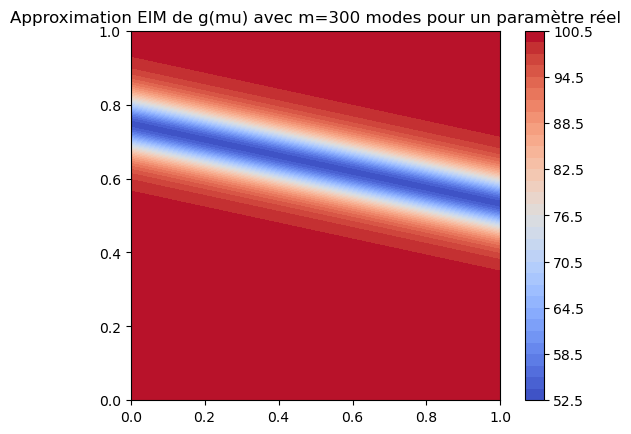

Visualisation de l'approximation EIM pour un paramètre réel: 100%|██████████| 6/6 [00:16<00:00,  2.73s/it]


Text(0.5, 1.0, 'Conductivité g(mu) pour le premier cas de test (FEniCS)')

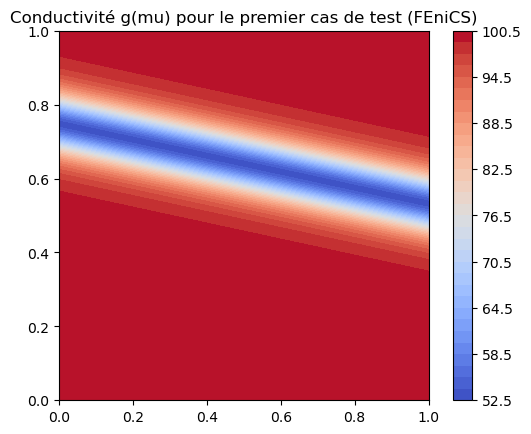

In [294]:
G_param = parameters_test_non_lineaire_list[2]
erreur_conductivite = np.zeros(len([10, 20, 40, 100, 200, 300]))
K_param = get_conductivity_Cinf(G_param)
K_fenics = project(K_param, V)
K_vect = K_fenics.vector().get_local()
for j, m in enumerate(tqdm([10, 20, 40, 100, 200, 300], desc="Visualisation de l'approximation EIM pour un paramètre réel")):
    G = np.array([K_vect[Magic_Points_Cinf[k]] for k in range(m)])
    beta = np.linalg.solve(B_complet_Cinf[:m, :m], G)
    g_f = beta @ Q_Cinf[:m, :]
    g_f_fenics = numpy_to_fenics_param(g_f, V)
    erreur_conductivite[j] = errornorm(K_fenics, g_f_fenics, 'L2')
    p = plot(g_f_fenics,
             cmap="coolwarm")
    plt.colorbar(p)
    plt.title(f"Approximation EIM de g(mu) avec m={m} modes pour un paramètre réel")
    plt.show()


plt.figure()
p = plot(K_fenics,
             cmap="coolwarm")
plt.colorbar(p)
plt.title("Conductivité g(mu) pour le premier cas de test (FEniCS)")

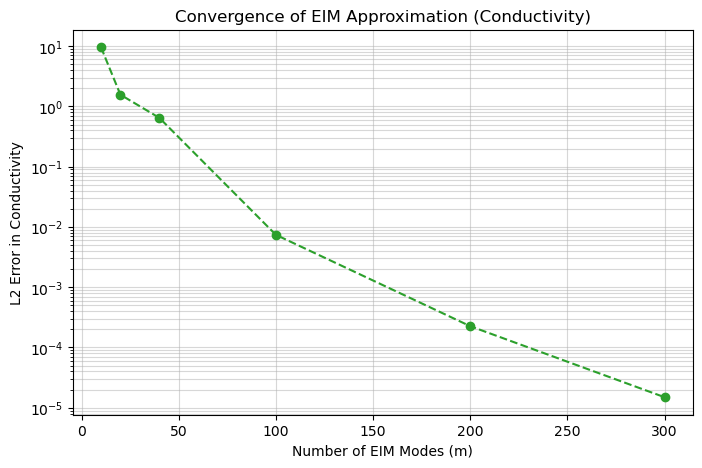

In [296]:
plt.figure(figsize=(8, 5))
plt.semilogy([10, 20, 40, 100, 200, 300], erreur_conductivite, marker='o', color='tab:green', linestyle='--')
plt.xlabel('Number of EIM Modes (m)')
plt.ylabel('L2 Error in Conductivity')
plt.title('Convergence of EIM Approximation (Conductivity)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [389]:
print("\nLancement du benchmark Online EIM...")

error_A_norm_EIM_Cinf = np.zeros(len(M_EIM))

for j, m in enumerate(tqdm(M_EIM, desc="Testing ROM with EIM")):
    
    for i, params in enumerate(parameters_test_non_lineaire_list):
        A_test_norme = A_test_list_Cinf[i]
        # Récupération de la conductivité de test pré-calculée
        g_mu_complet = g_test_list_Cinf[i]

        # ----------------------------------------------------
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ----------------------------------------------------
        t0 = time()
        
        # 1. On extrait comme de vrais "capteurs" physiques sur les Magic Points
        G = np.array([g_mu_complet[Magic_Points_Cinf[k]] for k in range(m)])
        
        # 2. Calcul des coefficients EIM
        beta = np.linalg.solve(B_complet_Cinf[:m, :m], G) 
        
        # 3. Assemblage réduit EIM pour la matrice A
        A_red_EIM = np.sum([beta[k] * A_reduit_EIM_Cinf_list[k] for k in range(m)], axis=0)
        
        # 4. CORRECTION MAGIQUE SUR LE SECOND MEMBRE b
        # On somme les parties qui dépendent VRAIMENT de la conductivité (conditions aux limites)
        b_var_EIM = np.sum([beta[k] * (b_reduit_EIM_Cinf_list[k] - b_source_red) for k in range(m)], axis=0)
        # Et on ajoute le terme source constant UNE SEULE FOIS
        b_red_EIM = b_source_red + b_var_EIM

        # 5. Résolution du petit système réduit
        u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        # 6. Reconstruction rapide NumPy
        u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect
        
        t1 = time()
        # ----------------------------------------------------
        # FIN DU CHRONO
        # ----------------------------------------------------
        
        # POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 
        
        # (Correction ici : on utilise bien HF_sol_list_Cinf)
        u_full = HF_sol_list_Cinf[i] 
        error_A_norm_EIM_Cinf[j] += error_A_norm(u_full, u_approx_fenics, A_test_norme)
        error_L2_EIM_Cinf[j] += error_L2(u_full, u_approx_fenics)
        time_EIM_Cinf[j] += (t1 - t0)

    # Moyennes
    error_A_norm_EIM_Cinf[j] /= len(parameters_test_non_lineaire_list)
    error_L2_EIM_Cinf[j] /= len(parameters_test_non_lineaire_list) 
    time_EIM_Cinf[j] /= len(parameters_test_non_lineaire_list)
    



Lancement du benchmark Online EIM...


Testing ROM with EIM: 100%|██████████| 10/10 [00:04<00:00,  2.08it/s]


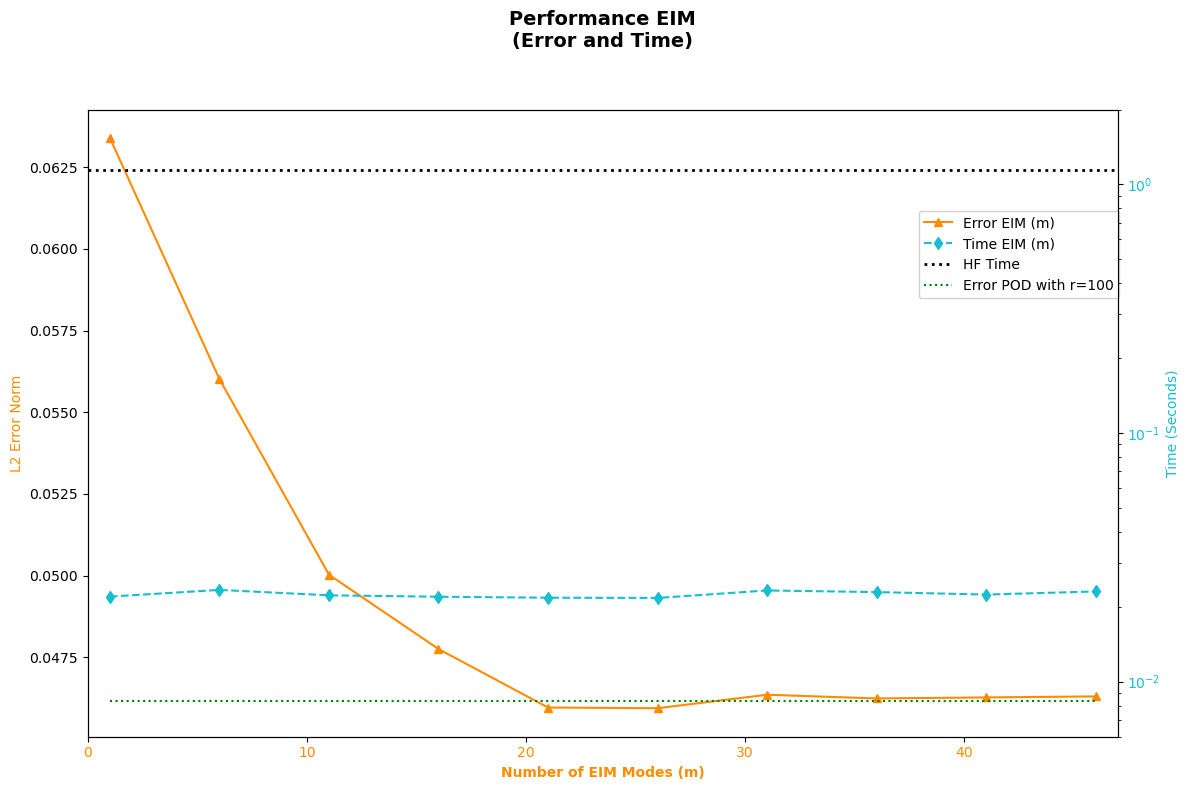

In [427]:

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# Erreur EIM (Bas / Gauche) -> Utilise l'axe Y gauche (ax1)
color_err_eim = 'darkorange'
ax1.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax1.plot(M_EIM, error_L2_EIM_Cinf, marker='^', 
               color=color_err_eim, label='Error EIM (m)')
ax1.tick_params(axis='x', labelcolor=color_err_eim)
ax1.set_ylabel('L2 Error Norm', color=color_err_eim)

# Ajout de la valeur théorique optimale en pointillés
l_opt = ax1.plot(M_EIM, [error_L2_non_lineaire[10] for r_EIM in M_EIM], 
                 marker='', linestyle=':', color='green', label='Error POD with r=100')

# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

ax2 = ax1.twinx()  # Partage l'axe X mais crée un nouvel axe Y droit
color_time_eim = 'tab:cyan'
l4, = ax2.semilogy(M_EIM, time_EIM_Cinf, marker='d', linestyle='--', 
                   color=color_time_eim, label='Time EIM (m)')
ax2.tick_params(axis='y', labelcolor=color_time_eim)
ax2.set_ylabel('Time (Seconds)', color=color_time_eim)
ax2.set_ylim(6e-3, 2e0)  # Ajuster les limites pour mieux visualiser les temps

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================

# Cacher la graduation X de ax4 car ax3 affiche déjà l'échelle "m" en haut
ax4.set_xticks([])
ax4.spines['top'].set_visible(False)

# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax1.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax2.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l3, l4, l_hf, l_opt[0]]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.8, 0.85), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance EIM\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

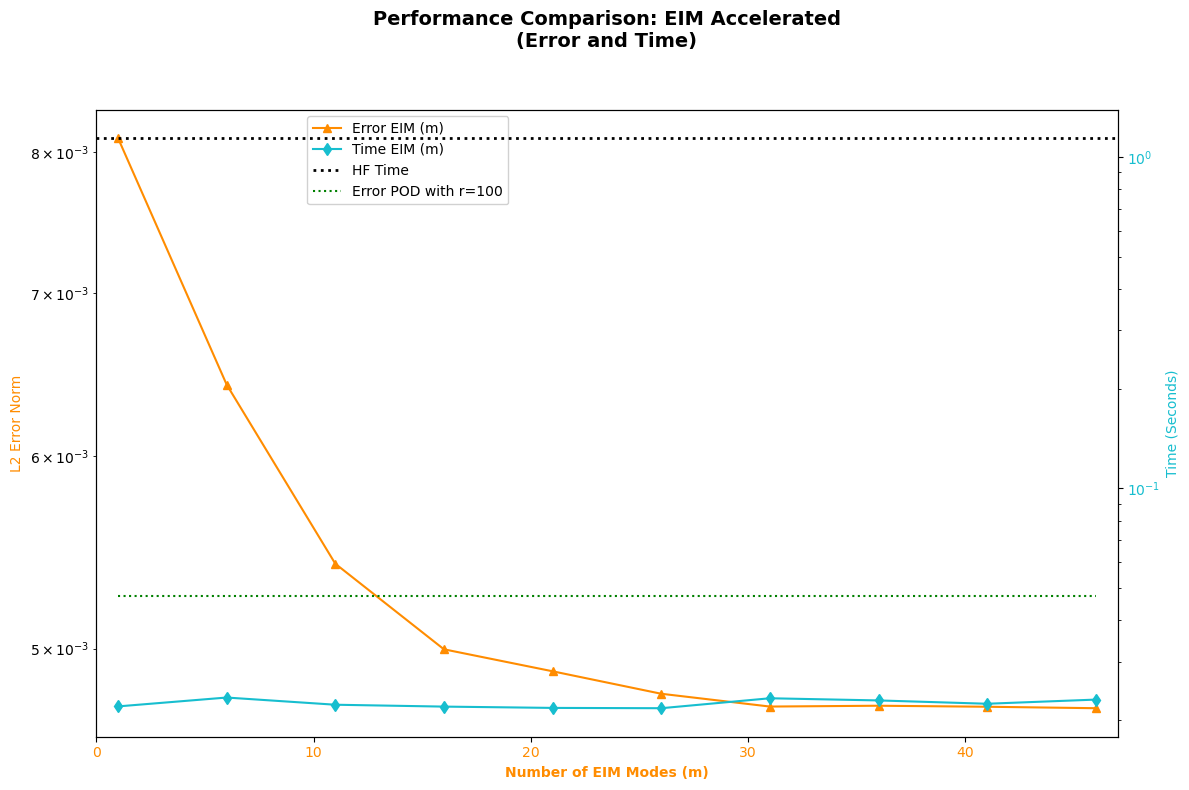

In [433]:
# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# Erreur EIM (Bas / Gauche) -> Utilise l'axe Y gauche (ax1)
color_err_eim = 'darkorange'
ax1.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax1.semilogy(M_EIM, error_A_norm_EIM_Cinf, marker='^', 
               color=color_err_eim, label='Error EIM (m)')
ax1.tick_params(axis='x', labelcolor=color_err_eim)
ax1.set_ylabel('L2 Error Norm', color=color_err_eim)

# Ajout de la valeur théorique optimale en pointillés
l_opt = ax1.semilogy(M_EIM, [error_A_non_lineaire[10] for r_EIM in M_EIM], 
                 marker='', linestyle=':', color='green', label='Error POD with r=100')

# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

ax2 = ax1.twinx()  # Partage l'axe X mais crée un nouvel axe Y droit
color_time_eim = 'tab:cyan'
l4, = ax2.semilogy(M_EIM, time_EIM_Cinf, marker='d', 
                   color=color_time_eim, label='Time EIM (m)')
ax2.tick_params(axis='y', labelcolor=color_time_eim)
ax2.set_ylabel('Time (Seconds)', color=color_time_eim)

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================

# Cacher la graduation X de ax4 car ax3 affiche déjà l'échelle "m" en haut
ax4.set_xticks([])
ax4.spines['top'].set_visible(False)

# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax1.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax2.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l3, l4, l_hf, l_opt[0]]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.2, 1), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance Comparison: EIM Accelerated\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

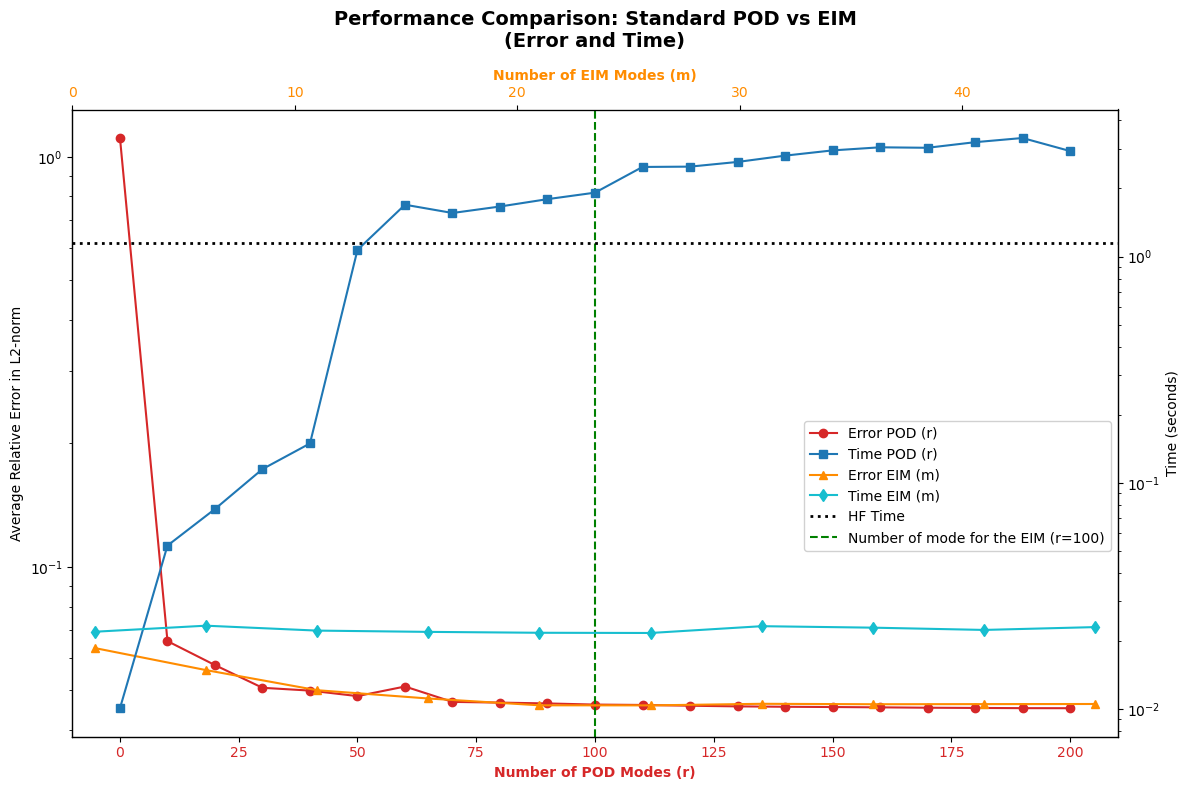

In [434]:

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# 1. Erreur POD pure (Bas / Gauche)
color_err_pod = 'tab:red'
ax1.set_xlabel('Number of POD Modes (r)', color=color_err_pod, fontweight='bold')
ax1.set_ylabel('Average Relative Error in L2-norm', color='black')
l1, = ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='o', 
                   color=color_err_pod, label='Error POD (r)')
ax1.tick_params(axis='x', labelcolor=color_err_pod)

l5 =ax1.axvline(x=100, color='green', linestyle='--', label='Number of mode for the EIM (r=100)')

# 2. Erreur EIM (Haut / Gauche) -> Partage l'axe Y gauche (ax1.twiny)
ax3 = ax1.twiny()
color_err_eim = 'darkorange'
ax3.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax3.semilogy(M_EIM, error_L2_EIM_Cinf, marker='^', 
                   color=color_err_eim, label='Error EIM (m)')
ax3.tick_params(axis='x', labelcolor=color_err_eim)


# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

# 3. Temps POD pure (Bas / Droite) -> Partage l'axe X bas (ax1.twinx)
ax2 = ax1.twinx()
color_time_pod = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color='black')
# J'ai mis semilogy ici pour que les temps soient comparables, tu peux remettre .plot si besoin
l2, = ax2.semilogy(Ns_non_lineaire_range, time_non_linear, marker='s', 
                   color=color_time_pod, label='Time POD (r)')

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# 4. Temps EIM (Haut / Droite) -> Partage l'axe Y droit et crée un nouvel axe X (ax2.twiny)
ax4 = ax2.twiny()
color_time_eim = 'tab:cyan'
l4, = ax4.semilogy(M_EIM, time_EIM_Cinf, marker='d',
                   color=color_time_eim, label='Time EIM (m)')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================

# Cacher la graduation X de ax4 car ax3 affiche déjà l'échelle "m" en haut
ax4.set_xticks([])
ax4.spines['top'].set_visible(False)

# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax3.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax4.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l1, l2, l3, l4, l_hf, l5]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='center right', bbox_to_anchor=(1, 0.4), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance Comparison: Standard POD vs EIM\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

In [330]:
V_r.shape

(160801, 100)

évolution de la solution approchée en fonction du nombre de modes EIM :


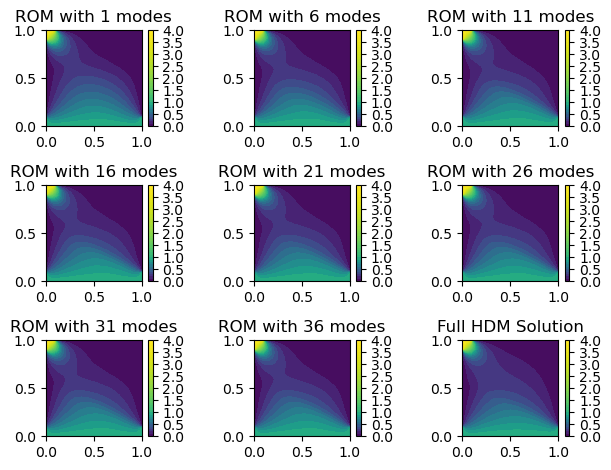

In [360]:
print("évolution de la solution approchée en fonction du nombre de modes EIM :")
for j, m in enumerate(range(1, 41, 5)):
    g_mu_complet = g_test_list_Cinf[0]  # On prend le premier cas de test pour visualiser l'évolution

        # ----------------------------------------------------
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ----------------------------------------------------
        
        # On extrait comme de vrais "capteurs" physiques sur les Magic Points
    G = np.array([g_mu_complet[Magic_Points_Cinf[k]] for k in range(m)])
        
        # Calcul des coefficients EIM (B[m-1] car l'index commence à 0)
    beta = np.linalg.solve(B_complet_Cinf[:m, :m], G) # orriginal 
        #beta = np.linalg.lstsq(B_complet_Cinf[:m, :m], G, rcond=None)[0] # Solution plus stable numériquement
        
        # Assemblage réduit EIM (Combinaison linéaire pure NumPy)
    A_red_EIM = np.sum([beta[k] * A_reduit_EIM_Cinf_list[k] for k in range(m)], axis=0)
    b_var_EIM = np.sum([beta[k] * (b_reduit_EIM_Cinf_list[k] - b_source_red) for k in range(m)], axis=0)
        # Et on ajoute le terme source constant UNE SEULE FOIS
    b_red_EIM = b_source_red + b_var_EIM
        # Résolution du petit système réduit
    u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        
        # Reconstruction rapide NumPy
    u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect

    u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 

    plt.subplot(3, 3, j + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {m} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(3, 3, 9)
u_full = HF_sol_list_Cinf[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Lancement du test de 'Reconstruction -> Réduction' (r = 100)...


Testing Assemble-then-Reduce: 100%|██████████| 6/6 [02:14<00:00, 22.46s/it]


Terminé ! Affichage des résultats de vérification :


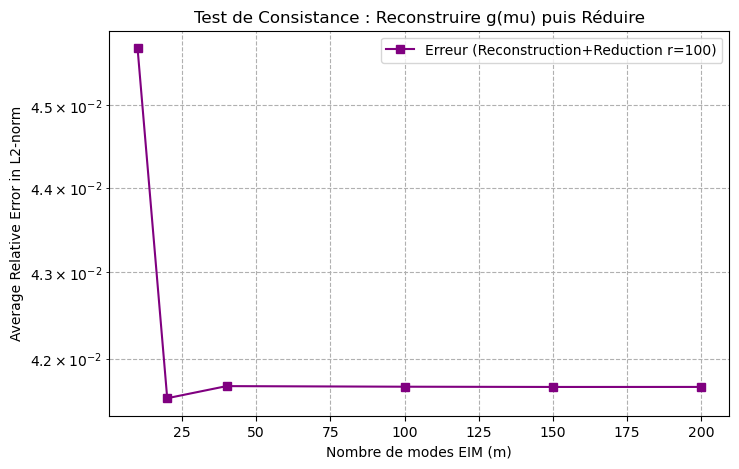

In [ ]:
# =========================================================
# CONFIGURATION DU TEST DE VÉRIFICATION
# =========================================================
r_verif = 100
V_r_verif = U_nl_Cinf[:, :r_verif]  # La fameuse base spatiale à tester

# On renomme les variables pour ne pas écraser tes autres tests
M_EIM_verif = [10, 20, 40, 100, 150, 200]
error_L2_Reconstruct_Cinf = np.zeros(len(M_EIM_verif))
time_Reconstruct_Cinf = np.zeros(len(M_EIM_verif))

print(f"Lancement du test de 'Reconstruction -> Réduction' (r = {r_verif})...")

for j, m in enumerate(tqdm(M_EIM_verif, desc="Testing Assemble-then-Reduce")):
    
    for i, params in enumerate(parameters_test_non_lineaire_list):

        # Récupération de la conductivité de test (le snapshot pur)
        g_mu_complet = g_test_list_Cinf[i]

        t0 = time()
        
        # ----------------------------------------------------
        # ÉTAPE 1 : Reconstruction parfaite de la conductivité (Courbe Verte)
        # ----------------------------------------------------
        G = np.array([g_mu_complet[Magic_Points_Cinf[k]] for k in range(m)])
        beta = np.linalg.solve(B_complet_Cinf[:m, :m], G) 
        
        # g_f contient le vecteur conductivité approché par EIM
        g_f = beta @ Q_Cinf[:m, :] 
        
        # ----------------------------------------------------
        # ÉTAPE 2 : Assemblage HF Direct (sans utiliser les A_reduit_EIM)
        # ----------------------------------------------------
        # On utilise ta fonction qui crée A et b à partir d'un vecteur numpy
        A_HF_approx, b_HF_approx = get_A_b_EIM(g_f)
        
        # ----------------------------------------------------
        # ÉTAPE 3 : Projection de la matrice (Réduction standard)
        # ----------------------------------------------------
        A_red_direct = build_reduced_stiffness(A_HF_approx, V_r_verif)
        b_red_direct = build_reduced_load(b_HF_approx, V_r_verif)

        # ----------------------------------------------------
        # ÉTAPE 4 : Résolution et Reconstruction
        # ----------------------------------------------------
        u_red_direct = np.linalg.solve(A_red_direct, b_red_direct)
        u_approx_direct = V_r_verif.dot(u_red_direct) + u_L_vect
        
        t1 = time()
        
        # ----------------------------------------------------
        # POST-TRAITEMENT ET CALCUL DE L'ERREUR
        # ----------------------------------------------------
        u_approx_fenics = numpy_to_fenics(u_approx_direct, V, u_L_vect) 
        
        # Attention à bien utiliser ta liste HF non linéaire !
        u_full = HF_sol_list_Cinf[i] 
        
        error_L2_Reconstruct_Cinf[j] += error_L2(u_full, u_approx_fenics)
        time_Reconstruct_Cinf[j] += (t1 - t0)

    # Moyennes
    error_L2_Reconstruct_Cinf[j] /= len(parameters_test_non_lineaire_list) 
    time_Reconstruct_Cinf[j] /= len(parameters_test_non_lineaire_list)

print("\nTerminé ! Affichage des résultats de vérification :")

# Visualisation pour comparer
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.semilogy(M_EIM_verif, error_L2_Reconstruct_Cinf, marker='s', color='purple', label=f'Erreur (Reconstruction+Reduction r={r_verif})')
plt.xlabel('Nombre de modes EIM (m)')
plt.ylabel('Average Relative Error in L2-norm')
plt.title('Test de Consistance : Reconstruire g(mu) puis Réduire')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

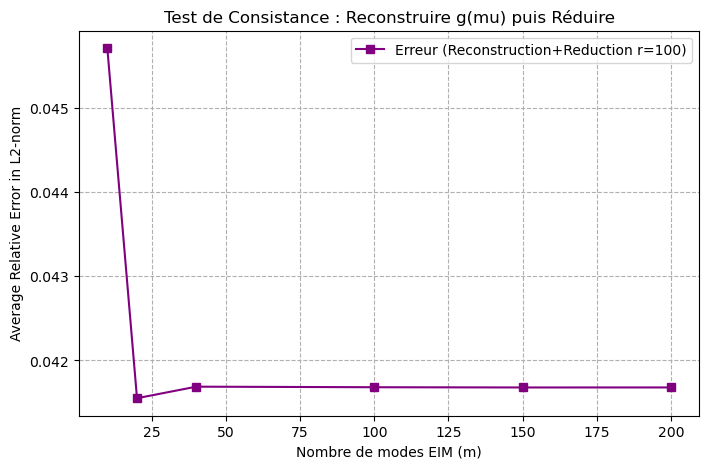

In [340]:
plt.figure(figsize=(8, 5))
plt.plot(M_EIM_verif, error_L2_Reconstruct_Cinf, marker='s', color='purple', label=f'Erreur (Reconstruction+Reduction r={r_verif})')
plt.xlabel('Nombre de modes EIM (m)')
plt.ylabel('Average Relative Error in L2-norm')
plt.title('Test de Consistance : Reconstruire g(mu) puis Réduire')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()